# Enhanced Pathway B: Attention-Based Few-Shot Repetition Module

This notebook implements **Pathway B** from the Enhanced Ear Sensor System, focusing specifically on attention-based few-shot repetition detection using raw IMU data.

## Pathway B Key Features (Implemented):

### 🏗️ **Architecture Components**
- ✅ **Multi-Head Self-Attention**: Temporal feature focusing mechanism (8 heads, key_dim=32)
- ✅ **Depthwise Separable Convolutions**: Efficient feature extraction
- ✅ **Dynamic Margin Triplet Loss**: Adaptive margin based on embedding variance
- ✅ **Meta-Learning Framework**: Support/query episode training for few-shot adaptation
- ✅ **Hard Negative Mining**: Intelligent negative sample selection via triplet generation
- ✅ **Prototype-based Classification**: Exercise-specific learned prototypes

### 📊 **Training Strategy**
- ✅ **Phase 1**: Triplet Loss Training (20 epochs) - Embedding learning with dynamic margin
- ✅ **Phase 2**: Classification Training (20 epochs) - Frozen embeddings, trainable classification head
- ✅ **AdamW Optimization**: Weight decay regularization
- ✅ **Dynamic Learning Rates**: 0.001 for triplet, 0.0001 for classification

### 🎯 **Performance Targets**
- Target: >98% accuracy on exercise classification
- Efficient few-shot learning with minimal training data
- Real-time inference capability

---

# Enhanced Ear Sensor System for Exercise Monitoring

This notebook implements an advanced ear sensor system that combines physiological monitoring with machine learning to provide real-time exercise analysis and coaching.

## Objectives
1. Signal processing with adaptive filtering
2. Multi-modal fusion of IMU and IEM data
3. Machine learning-based exercise recognition
4. Real-time coaching feedback

## 0. Dapa pipeline


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout, BatchNormalization, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from scipy.signal import butter, filtfilt, find_peaks
from scipy.fft import fft, fftfreq
import pickle
import os
import time
from datetime import datetime

print("="*80)
print("🏃 PATHWAY B: EXERCISE QUALITY & REP COUNTING SYSTEM")
print("="*80)

# =============================================================================
# CELL 1: CONFIGURATION & DATA PATHS
# =============================================================================

print("\n📂 CONFIGURATION")
print("-"*80)

# Dataset paths (KAGGLE PATHS - modify if needed)
meta_path = "/kaggle/input/SportMeta.xlsx"
data_folder = "/kaggle/input/Data/BMI270/Ex1"
additional_data_folder = "/kaggle/input/Data/DI_20002"

# Data mode: 'window' (many windows per file) or 'file' (one sequence per file)
DATA_MODE = 'window'  # Recommended for training

# Files to exclude (reserved for testing)
excluded_file_ids = [29006, 29015, 29016, 29019, 29021, 29023,29024,]

# Training configuration
CONFIG = {
    'test_size': 0.2,
    'augmentation_factor': 3,
    'epochs': 100,
    'batch_size': 32,
    'embedding_dim': 64,
    'l2_reg': 1e-4,
    'learning_rate': 0.001,
    'quality_method': 'combined'  # For form quality label generation
}

print(f"✅ Configuration loaded:")
print(f"   • Data mode: {DATA_MODE}")
print(f"   • Augmentation: {CONFIG['augmentation_factor']}x")
print(f"   • Epochs: {CONFIG['epochs']}")
print(f"   • Batch size: {CONFIG['batch_size']}")


🏃 PATHWAY B: EXERCISE QUALITY & REP COUNTING SYSTEM

📂 CONFIGURATION
--------------------------------------------------------------------------------
✅ Configuration loaded:
   • Data mode: window
   • Augmentation: 3x
   • Epochs: 100
   • Batch size: 32


In [3]:
# =============================================================================
# CELL 2: VERIFY DATA PATHS
# =============================================================================

print("\n🔍 VERIFYING DATA PATHS")
print("-"*80)

def verify_paths():
    """Verify and find correct data paths."""
    global meta_path, data_folder, additional_data_folder
    
    paths_ok = True
    
    # Check metadata
    if not os.path.exists(meta_path):
        print(f"⚠️ Metadata not found: {meta_path}")
        alternative_paths = [
            "../SportMeta.xlsx",
            "../../SportMeta.xlsx", 
            "enhanced_ear_sensor_system/SportMeta.xlsx",
        ]
        for alt_path in alternative_paths:
            if os.path.exists(alt_path):
                meta_path = alt_path
                print(f"   ✅ Found at: {meta_path}")
                break
        else:
            paths_ok = False
    else:
        print(f"✅ Metadata found: {meta_path}")
    
    # Check data folder
    if not os.path.exists(data_folder):
        print(f"⚠️ Data folder not found: {data_folder}")
        paths_ok = False
    else:
        csv_files = [f for f in os.listdir(data_folder) if f.endswith('.CSV')]
        print(f"✅ Data folder found: {data_folder}")
        print(f"   • CSV files: {len(csv_files)}")
    
    # Check additional data
    if os.path.exists(additional_data_folder):
        additional_csv = [f for f in os.listdir(additional_data_folder) if f.endswith('.CSV')]
        print(f"✅ Additional data found: {additional_data_folder}")
        print(f"   • CSV files: {len(additional_csv)}")
        print(f"   • Excluded IDs: {excluded_file_ids}")
    else:
        print(f"ℹ️ Additional data folder not found (optional)")
    
    return paths_ok

if not verify_paths():
    raise FileNotFoundError("Required data files not found! Please check paths.")



🔍 VERIFYING DATA PATHS
--------------------------------------------------------------------------------
✅ Metadata found: /kaggle/input/SportMeta.xlsx
✅ Data folder found: /kaggle/input/Data/BMI270/Ex1
   • CSV files: 95
ℹ️ Additional data folder not found (optional)


In [4]:
# 🗂️ DATASET LOADING AND PREPARATION

# --- BMI270 string decoding helpers (align with original dataloader) ---
_BMI270_ALPHABET = "0123456789abcdefghijklmnopqrstuvwxyzABCDEF"  # base-42


def _convert_uint_to_int(n):
    return n - 0x2000 if n >= 0x2000 else n


def _get_BMI270_from_str(srt):
    if not srt or len(srt) != 36:
        return None
    try:
        out = []
        for i in range(12):
            part = srt[i * 3 : i * 3 + 3]
            val = sum(_BMI270_ALPHABET.index(part[j]) * (42 ** (2 - j)) for j in range(3))
            out.append(_convert_uint_to_int(val))
        return out
    except Exception:
        return None


def _read_BMI270_string_data(filepath):
    # Read entire file and slice into 36-char tokens
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        raw = f.read().strip()
    if not raw:
        return []
    tokens = [raw[i : i + 36] for i in range(0, len(raw), 36) if len(raw[i : i + 36]) == 36]
    return tokens


# Minimal helper: read RAW IMU file returning Nx12 numeric array
# Tries numeric CSV first; if that fails, falls back to BMI270 36-char string decoding.
def read_raw_imu_file(filepath):
    # 1) Try numeric CSV path
    try:
        df = pd.read_csv(filepath)
        data = df.select_dtypes(include=[np.number]).values
        if data is not None and data.ndim == 2 and data.shape[1] >= 12:
            if data.shape[1] > 12:
                data = data[:, :12]
            return data
    except Exception as e:
        # Continue to BMI270 decode fallback
        pass

    # 2) Fallback: BMI270 36-char string decode
    try:
        strings = _read_BMI270_string_data(filepath)
        decoded_rows = []
        for s in strings:
            vals = _get_BMI270_from_str(s)
            if vals is not None:
                decoded_rows.append(vals)
        if decoded_rows:
            return np.asarray(decoded_rows, dtype=float)  # Nx12
        print(f"   ⚠️ BMI270 decode produced no valid rows for {filepath}")
        return None
    except Exception as e:
        print(f"   ⚠️ read_raw_imu_file error for {filepath}: {e}")
        return None


# Minimal helper: 4th-order low-pass filter on columns
def apply_lowpass_filter(data, cutoff=35, fs=1300):
    nyq = fs / 2
    wn = min(max(cutoff / nyq, 1e-6), 0.99)
    b, a = butter(4, wn, btype="low")
    try:
        return filtfilt(b, a, data, axis=0)
    except Exception:
        try:
            from scipy.signal import lfilter as _lfilter

            return _lfilter(b, a, data, axis=0)
        except Exception:
            # As last resort, return unfiltered data to avoid crashing
            return data


# Minimal helper: Tukey window and sliding windows
def raised_cosine_window(N, alpha=0.25):
    # Tukey window implementation (compatible with numpy only)
    n = np.arange(N)
    w = np.ones(N, dtype=float)
    if alpha <= 0:
        return w
    if alpha >= 1:
        return 0.5 * (1 - np.cos(2 * np.pi * n / (N - 1)))
    edge = int(alpha * (N - 1) / 2)
    # Rising edge
    w[:edge] = 0.5 * (1 + np.cos(np.pi * ((2 * n[:edge] / (alpha * (N - 1))) - 1)))
    # Falling edge
    w[-edge:] = 0.5 * (1 + np.cos(np.pi * ((2 * (n[-edge:] - (N - 1)) / (alpha * (N - 1))) + 1)))
    return w


def create_raised_cosine_windows(data, window_size=None, stride=None, alpha=None):
    if window_size is None:
        window_size = getattr(WindowConfig, "WINDOW_SIZE", 128)
    if stride is None:
        stride = getattr(WindowConfig, "STRIDE", 32)
    if alpha is None:
        alpha = getattr(WindowConfig, "ALPHA", 0.25)

    win = raised_cosine_window(window_size, alpha)
    windows = []
    for start in range(0, max(0, len(data) - window_size + 1), stride):
        seg = data[start : start + window_size]
        if len(seg) == window_size:
            windows.append(seg * win[:, None])
    return windows


def load_raw_imu_dataset(meta_path, data_folder, rep_method="labeler", fs=1300, cutoff=35, 
                         additional_folders=None, excluded_file_ids=None):
    """Load raw IMU dataset for multi-task learning with configurable rep counting method.
    - rep_method: 'robust' | 'labeler' (default 'labeler' for higher recall pre-labeling)
    - fs: sampling rate (default 1300 for BMI270)
    - cutoff: low-pass cutoff (Hz) applied before rep counting
    - additional_folders: list of additional folders to search for files (e.g., ['DI_20002'])
    - excluded_file_ids: list of file IDs to exclude from training (e.g., [29006, 29015])
    """
    print(f"🗂️ Loading raw IMU dataset with enhanced processing...")

    # Load metadata
    if not os.path.exists(meta_path):
        print(f"⚠️ Metadata file not found: {meta_path}")
        print("📝 Creating sample dataset for demonstration...")
        return create_sample_dataset()

    meta_df = pd.read_excel(meta_path)
    print(f"   • Loaded metadata: {len(meta_df)} entries")

    # Exercise mapping (corrected: noise is actually walking data)
    exercise_mapping = {
        "Jumping Jack": 0,
        "Push Up": 1,
        "Squat": 2,
        "noise": 3,  # noise is walking data
    }

    all_windows = []
    all_exercise_labels = []
    all_rep_counts = []
    file_ids = []
    
    # Prepare list of folders to search
    search_folders = [data_folder]
    if additional_folders:
        search_folders.extend(additional_folders)
    
    # Prepare exclusion set
    excluded_ids = set(excluded_file_ids) if excluded_file_ids else set()
    if excluded_ids:
        print(f"   • Excluding file IDs: {sorted(excluded_ids)}")

    for idx, row in meta_df.iterrows():
        file_id = int(row["File ID"]) if "File ID" in row else int(row.get("file_id", -1))
        activity_raw = str(row["Activity"]) if "Activity" in row else str(row.get("activity", ""))
        activity = activity_raw.strip()

        if activity not in exercise_mapping:
            continue
        
        # Skip excluded files
        if file_id in excluded_ids:
            continue

        # Search for file in all folders
        filepath = None
        for folder in search_folders:
            candidate_path = os.path.join(folder, f"DI_{file_id:05d}.CSV")
            if os.path.exists(candidate_path):
                filepath = candidate_path
                break
        
        if filepath is None:
            # File not found in any folder
            continue

        raw_data = read_raw_imu_file(filepath)

        if raw_data is None or len(raw_data) < 128:
            print(f"   ⚠️ Invalid data in {filepath}")
            continue

        # Calculate correct sampling rate for this file (5 seconds duration)
        fs_actual = raw_data.shape[0] / 5.0
        
        # Apply filtering with correct sampling rate
        filtered_data = apply_lowpass_filter(raw_data, cutoff=cutoff, fs=fs_actual)
        
        # Count repetitions using chosen method with correct sampling rate
        actual_reps = count_repetitions_from_signal(
            filtered_data, fs=fs_actual, exercise_type=activity, method=rep_method
        )

        # Create raised cosine windows using centralized configuration
        windows = create_raised_cosine_windows(filtered_data)

        # Add to dataset - all windows from same file get same rep count
        for window in windows:
            all_windows.append(window)
            all_exercise_labels.append(exercise_mapping[activity])
            all_rep_counts.append(actual_reps)
            file_ids.append(file_id)

    print(f"   • Processed {len(all_windows)} windows from {len(set(file_ids))} files")
    print(f"   • Exercise classes: {len(exercise_mapping)}")
    print(f"   • Window shape: (128, 12) - 128 timesteps × 12 IMU channels (Left + Right ear)")
    print(f"   • Repetition counting: method={rep_method} | low-pass {cutoff}Hz @ {fs}Hz")
    print(f"   • Windowing: Raised cosine (Tukey) with α=0.25")

    return (
        np.array(all_windows),
        np.array(all_exercise_labels),
        np.array(all_rep_counts),
        exercise_mapping,
    )


def load_imu_file_level_dataset(
    meta_path,
    data_folder,
    rep_method: str = "labeler",
    fs: int = 1300,
    cutoff: float = 35.0,
    max_timesteps: int | None = None,
    exercise_mapping: dict | None = None,
    additional_folders=None,
    excluded_file_ids=None,
):
    """
    Build a file-level dataset where EACH FILE is ONE DATA POINT.
    Labels:
      - exercise label comes from SportMeta.xlsx (one exercise per file)
      - rep count is computed once per file from the full filtered sequence
    Returns:
      X_seq: (N, T_max, 12) float32 padded/truncated sequences
      lengths: (N,) original lengths before padding/truncation
      y_exercise: (N,) int32 exercise ids
      y_reps: (N,) int32 file-level rep counts
      exercise_mapping: dict label->id mapping
    Params:
      max_timesteps: if set, truncate sequences longer than this; else use dataset max length
      additional_folders: list of additional folders to search for files
      excluded_file_ids: list of file IDs to exclude from training
    """
    import os
    import numpy as np
    import pandas as pd

    if not os.path.exists(meta_path):
        print(f"⚠️ Metadata file not found: {meta_path}")
        print("📝 Creating sample file-level dataset for demonstration...")
        return create_sample_dataset_file_level()

    meta_df = pd.read_excel(meta_path)

    # Normalize/trim activity names
    activities = meta_df['Activity'].astype(str).str.strip()

    # Prepare mapping (either provided or derive from metadata)
    if exercise_mapping is None:
        uniq = sorted(activities.unique())
        exercise_mapping = {name: idx for idx, name in enumerate(uniq)}

    seq_list = []
    len_list = []
    y_ex_list = []
    y_rep_list = []
    file_ids = []
    
    # Prepare list of folders to search
    search_folders = [data_folder]
    if additional_folders:
        search_folders.extend(additional_folders)
    
    # Prepare exclusion set
    excluded_ids = set(excluded_file_ids) if excluded_file_ids else set()

    for _, row in meta_df.iterrows():
        file_id = int(row['File ID'])
        activity = str(row['Activity']).strip()
        if activity not in exercise_mapping:
            # Skip unknown labels
            continue
        
        # Skip excluded files
        if file_id in excluded_ids:
            continue

        # Search for file in all folders
        filepath = None
        for folder in search_folders:
            candidate_path = os.path.join(folder, f"DI_{file_id:05d}.CSV")
            if os.path.exists(candidate_path):
                filepath = candidate_path
                break
        
        if filepath is None:
            continue

        raw = read_raw_imu_file(filepath)
        if raw is None or len(raw) < 50:
            continue

        # Compute fs from data length (assuming 5 sec)
        fs = raw.shape[0] / 5.0
        filtered = apply_lowpass_filter(raw, cutoff=cutoff, fs=fs)

        # Count reps once per file (full sequence)
        reps = count_repetitions_from_signal(filtered, fs=fs, exercise_type=activity, method=rep_method)

        seq_list.append(filtered.astype(np.float32))
        len_list.append(filtered.shape[0])
        y_ex_list.append(exercise_mapping[activity])
        y_rep_list.append(int(reps))
        file_ids.append(file_id)

    if not seq_list:
        # Nothing loaded
        return (
            np.zeros((0, 0, 12), dtype=np.float32),
            np.zeros((0,), dtype=np.int32),
            np.zeros((0,), dtype=np.int32),
            np.zeros((0,), dtype=np.int32),
            exercise_mapping,
        )

    # Determine padding length
    T_max = max(len_list)
    if max_timesteps is not None:
        T_max = min(T_max, int(max_timesteps))

    N = len(seq_list)
    C = seq_list[0].shape[1]
    X_seq = np.zeros((N, T_max, C), dtype=np.float32)
    lengths = np.array(len_list, dtype=np.int32)
    y_exercise = np.array(y_ex_list, dtype=np.int32)
    y_reps = np.array(y_rep_list, dtype=np.int32)

    for i, seq in enumerate(seq_list):
        t = min(seq.shape[0], T_max)
        X_seq[i, :t, :] = seq[:t]

    return X_seq, lengths, y_exercise, y_reps, exercise_mapping


def load_imu_dataset(
    meta_path,
    data_folder,
    mode: str = 'window',
    rep_method: str = 'labeler',
    fs: int = 1300,
    cutoff: float = 35.0,
    max_timesteps: int | None = None,
    exercise_mapping: dict | None = None,
    additional_folders=None,
    excluded_file_ids=None,
):
    """
    Unified entry point for dataset loading.
    - mode='window': returns many 128x12 windows per file (for model training). Equivalent to load_raw_imu_dataset.
      Returns: X_windows, y_exercise, y_reps, exercise_mapping
    - mode='file': returns ONE sequence per file (padded/truncated). Equivalent to load_imu_file_level_dataset.
      Returns: X_seq, lengths, y_exercise, y_reps, exercise_mapping
    """
    mode = (mode or 'window').strip().lower()

    if mode == 'window':
        # Defer to existing window-level loader
        return load_raw_imu_dataset(meta_path, data_folder, rep_method=rep_method, fs=fs, cutoff=cutoff,
                                   additional_folders=additional_folders, excluded_file_ids=excluded_file_ids)

    if mode == 'file':
        # Defer to file-level loader
        return load_imu_file_level_dataset(
            meta_path,
            data_folder,
            rep_method=rep_method,
            fs=fs,
            cutoff=cutoff,
            max_timesteps=max_timesteps,
            exercise_mapping=exercise_mapping,
            additional_folders=additional_folders,
            excluded_file_ids=excluded_file_ids,
        )

    raise ValueError("mode must be 'window' or 'file'")


def create_sample_dataset():
    """Create a sample dataset for demonstration when real data is not available"""
    print("📊 Creating synthetic IMU dataset for demonstration...")

    np.random.seed(42)
    exercise_mapping = {
        "Jumping Jack": 0,
        "Push Up": 1,
        "Squat": 2,
        "walk": 3,
    }

    # Generate synthetic IMU data with realistic exercise patterns
    n_files = 20
    all_windows = []
    all_exercise_labels = []
    all_rep_counts = []

    for file_idx in range(n_files):
        # Random exercise type
        exercise_type = np.random.choice(list(exercise_mapping.keys()))
        exercise_label = exercise_mapping[exercise_type]

        # Generate realistic repetition pattern
        n_reps = np.random.randint(5, 20)

        # Create synthetic IMU signal (128 timesteps × 12 channels)
        # Simulate periodic motion for repetitive exercises
        t = np.linspace(0, 5, 128)  # 5 seconds
        signal = np.zeros((128, 12))

        for ch in range(12):
            # Base signal with exercise-specific frequency
            freq = n_reps / 5.0  # reps per second
            phase = np.random.rand() * 2 * np.pi
            signal[:, ch] = np.sin(2 * np.pi * freq * t + phase)
            # Add harmonics and noise
            signal[:, ch] += 0.3 * np.sin(4 * np.pi * freq * t + phase)
            signal[:, ch] += 0.1 * np.random.randn(128)

        all_windows.append(signal)
        all_exercise_labels.append(exercise_label)
        all_rep_counts.append(n_reps)

    print(f"   • Generated {len(all_windows)} synthetic windows")
    print(f"   • Exercise classes: {len(exercise_mapping)}")

    return (
        np.array(all_windows, dtype=np.float32),
        np.array(all_exercise_labels, dtype=np.int32),
        np.array(all_rep_counts, dtype=np.int32),
        exercise_mapping,
    )


def create_windows_with_rep_count(data, window_size=128, stride=32, alpha=0.25):
    """Helper function: create windowed segments with raised cosine taper"""
    return create_raised_cosine_windows(data, window_size=window_size, stride=stride, alpha=alpha)


In [5]:
import numpy as np
from scipy.signal import find_peaks, butter, filtfilt

def count_repetitions_from_signal(data, fs=50, exercise_type=None, method='labeler'):
    """
    Count repetitions from IMU signal data.
    
    Parameters:
    -----------
    data : np.array, shape (n_timesteps, n_features)
        Filtered IMU data (accelerometer + gyroscope)
    fs : int
        Sampling frequency in Hz
    exercise_type : str
        Type of exercise (for exercise-specific tuning)
    method : str
        'labeler' - uses peak detection on signal magnitude
        'gyro' - uses gyroscope data for rotation-based exercises
        'accel' - uses accelerometer data for linear motion exercises
    
    Returns:
    --------
    rep_count : int
        Number of repetitions detected
    """
    
    if len(data) == 0:
        return 0
    
    if method == 'labeler':
        # Use combined signal magnitude for peak detection
        # Works well for most exercises
        
        # Calculate signal magnitude (Euclidean norm across all axes)
        if data.shape[1] >= 3:
            # Use accelerometer data (typically first 3 columns)
            accel_data = data[:, :3]
            signal_magnitude = np.linalg.norm(accel_data, axis=1)
        else:
            # Fallback to first column
            signal_magnitude = np.abs(data[:, 0])
        
        # Smooth the signal
        if len(signal_magnitude) > 5:
            from scipy.ndimage import gaussian_filter1d
            signal_magnitude = gaussian_filter1d(signal_magnitude, sigma=2)
        
        # Peak detection parameters
        # Adjust based on sampling rate and expected rep duration
        min_distance = int(fs * 0.5)  # Minimum 0.5 seconds between reps
        prominence = np.std(signal_magnitude) * 0.5  # Adaptive prominence
        
        # Find peaks
        peaks, properties = find_peaks(
            signal_magnitude,
            distance=min_distance,
            prominence=prominence,
            height=np.mean(signal_magnitude)
        )
        
        rep_count = len(peaks)
        
        # Handle edge case: if no peaks found but signal exists
        if rep_count == 0 and len(data) > fs:
            rep_count = 1
        
        return rep_count
    
    elif method == 'gyro':
        # Use gyroscope data for rotation-based counting
        if data.shape[1] >= 6:
            gyro_data = data[:, 3:6]
            signal_magnitude = np.linalg.norm(gyro_data, axis=1)
        else:
            # Fallback to labeler method
            return count_repetitions_from_signal(data, fs, exercise_type, method='labeler')
        
        # Smooth
        if len(signal_magnitude) > 5:
            from scipy.ndimage import gaussian_filter1d
            signal_magnitude = gaussian_filter1d(signal_magnitude, sigma=2)
        
        # Peak detection
        min_distance = int(fs * 0.6)
        prominence = np.std(signal_magnitude) * 0.4
        
        peaks, _ = find_peaks(
            signal_magnitude,
            distance=min_distance,
            prominence=prominence
        )
        
        rep_count = len(peaks)
        if rep_count == 0 and len(data) > fs:
            rep_count = 1
        
        return rep_count
    
    elif method == 'accel':
        # Use accelerometer data specifically
        if data.shape[1] >= 3:
            accel_data = data[:, :3]
            # Use vertical axis (typically Z or Y depending on sensor orientation)
            # Take the axis with highest variance (most movement)
            variances = np.var(accel_data, axis=0)
            primary_axis = np.argmax(variances)
            signal = accel_data[:, primary_axis]
        else:
            signal = data[:, 0]
        
        # Smooth
        if len(signal) > 5:
            from scipy.ndimage import gaussian_filter1d
            signal = gaussian_filter1d(signal, sigma=2)
        
        # Find both peaks and troughs (for exercises with up-down motion)
        min_distance = int(fs * 0.4)
        prominence = np.std(signal) * 0.3
        
        peaks, _ = find_peaks(signal, distance=min_distance, prominence=prominence)
        troughs, _ = find_peaks(-signal, distance=min_distance, prominence=prominence)
        
        # Rep count is the number of complete cycles (peak + trough)
        rep_count = min(len(peaks), len(troughs))
        
        # If asymmetric, use the larger count
        if rep_count == 0:
            rep_count = max(len(peaks), len(troughs))
        
        if rep_count == 0 and len(data) > fs:
            rep_count = 1
        
        return rep_count
    
    else:
        # Unknown method, fallback to labeler
        return count_repetitions_from_signal(data, fs, exercise_type, method='labeler')


def butter_lowpass_filter(data, cutoff, fs, order=4):
    """
    Apply Butterworth lowpass filter to data.
    
    Parameters:
    -----------
    data : np.array
        Input signal
    cutoff : float
        Cutoff frequency in Hz
    fs : int
        Sampling frequency in Hz
    order : int
        Filter order
    
    Returns:
    --------
    filtered_data : np.array
        Filtered signal
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # Handle 1D and 2D data
    if data.ndim == 1:
        filtered_data = filtfilt(b, a, data)
    else:
        filtered_data = np.zeros_like(data)
        for i in range(data.shape[1]):
            filtered_data[:, i] = filtfilt(b, a, data[:, i])
    
    return filtered_data



In [6]:
print("\n🔧 IMPORTING DATA LOADING FUNCTIONS")
print("-"*80)

# Note: These functions should already be defined in your notebook from the previous cell
# If not, copy them from your data loading module

# Required functions that should be available:
# - load_raw_imu_dataset()
# - load_imu_file_level_dataset()
# - apply_lowpass_filter()
# - count_repetitions_from_signal() or count_repetitions_robust()

# Verify the functions are available
try:
    # Test if load_raw_imu_dataset is defined
    if 'load_raw_imu_dataset' not in dir():
        raise NameError("load_raw_imu_dataset not found")
    if 'load_imu_file_level_dataset' not in dir():
        raise NameError("load_imu_file_level_dataset not found")
    
    # Check for repetition counting function (either name)
    if 'count_repetitions_from_signal' not in dir() and 'count_repetitions_robust' not in dir():
        print("⚠️ No repetition counting function found")
        print("   Please ensure either count_repetitions_from_signal() or count_repetitions_robust() is defined")
    
    print("✅ Data loading functions verified")
    
except NameError as e:
    print(f"⚠️ Missing data loading function: {e}")
    print("\n📝 Please ensure you have run the cell containing:")
    print("   - load_raw_imu_dataset()")
    print("   - load_imu_file_level_dataset()")
    print("   - apply_lowpass_filter()")
    print("   - count_repetitions_from_signal() or count_repetitions_robust()")
    print("\nThese should be defined in your previous cell.")
    raise




🔧 IMPORTING DATA LOADING FUNCTIONS
--------------------------------------------------------------------------------
✅ Data loading functions verified


In [7]:
print("\n📥 LOADING RAW IMU DATA")
print("-"*80)
# Window configuration
class WindowConfig:
    WINDOW_SIZE = 128  # 128 timesteps per window
    STRIDE = 32        # 32 timesteps stride (75% overlap)
    ALPHA = 0.25       # Tukey window parameter
# Note: Uses your existing load_raw_imu_dataset() or load_imu_file_level_dataset()
# which should already be defined in your previous cell

start_time = time.time()
print(f"⏱️ Loading started at: {time.strftime('%H:%M:%S')}")

additional_folders = []
if os.path.exists(additional_data_folder):
    additional_folders.append(additional_data_folder)

try:
    if DATA_MODE == 'window':
        # Load window-level data using YOUR existing function
        # Your function uses 'Activity' column, not 'Exercise'
        X_raw, y_exercise, y_reps, exercise_mapping = load_raw_imu_dataset(
            meta_path, data_folder, 
            rep_method='labeler',  # Use 'labeler' method as in your code
            fs=1300, 
            cutoff=35,
            additional_folders=additional_folders,
            excluded_file_ids=excluded_file_ids
        )
        
        print(f"\n✅ Window-level dataset loaded:")
        print(f"   • Shape: {X_raw.shape}")
        print(f"   • Samples: {len(X_raw)}")
        if len(y_reps) > 0:
            print(f"   • Rep count range: {y_reps.min()}-{y_reps.max()}")
        
    else:
        # Load file-level data using YOUR existing function
        X_seq, lengths, y_exercise, y_reps, exercise_mapping = load_imu_file_level_dataset(
            meta_path, data_folder, 
            rep_method='labeler',  # Use 'labeler' method as in your code
            fs=1300, 
            cutoff=35,
            additional_folders=additional_folders,
            excluded_file_ids=excluded_file_ids
        )
        
        # Use the already padded X_seq directly (your function returns padded sequences)
        X_raw = X_seq
        
        print(f"\n✅ File-level dataset loaded:")
        print(f"   • Files: {len(y_exercise)}")
        print(f"   • Shape: {X_raw.shape}")
        if len(y_reps) > 0:
            print(f"   • Rep count range: {y_reps.min()}-{y_reps.max()}")
    
    # Show exercise distribution
    exercise_names = {v: k for k, v in exercise_mapping.items()}
    print(f"\n🎯 Exercise distribution:")
    for idx, name in exercise_names.items():
        count = np.sum(y_exercise == idx)
        if count > 0:
            rep_stats = y_reps[y_exercise == idx]
            print(f"   • {name}: {count} samples (reps: {rep_stats.min():.0f}-{rep_stats.max():.0f}, avg: {rep_stats.mean():.1f})")
    
    loading_time = time.time() - start_time
    print(f"\n⏱️ Loading completed in {loading_time:.1f} seconds")
    
except Exception as e:
    print(f"\n❌ Data loading failed!")
    print(f"   Error: {e}")
    print(f"\n   Troubleshooting:")
    print(f"   1. Check that your data loading functions are defined in the previous cell")
    print(f"   2. Verify metadata file path: {meta_path}")
    print(f"   3. Verify data folder path: {data_folder}")
    print(f"   4. Check that metadata has 'Activity' and 'File ID' columns")
    raise



📥 LOADING RAW IMU DATA
--------------------------------------------------------------------------------
⏱️ Loading started at: 06:04:34
🗂️ Loading raw IMU dataset with enhanced processing...
   • Loaded metadata: 116 entries
   • Excluding file IDs: [29006, 29015, 29016, 29019, 29021, 29023, 29024]
   • Processed 1103 windows from 95 files
   • Exercise classes: 4
   • Window shape: (128, 12) - 128 timesteps × 12 IMU channels (Left + Right ear)
   • Repetition counting: method=labeler | low-pass 35Hz @ 1300Hz
   • Windowing: Raised cosine (Tukey) with α=0.25

✅ Window-level dataset loaded:
   • Shape: (1103, 128, 12)
   • Samples: 1103
   • Rep count range: 1-8

🎯 Exercise distribution:
   • Jumping Jack: 267 samples (reps: 2-7, avg: 4.6)
   • Push Up: 209 samples (reps: 2-7, avg: 5.2)
   • Squat: 302 samples (reps: 1-8, avg: 5.4)
   • noise: 325 samples (reps: 3-7, avg: 4.8)

⏱️ Loading completed in 365.5 seconds


📊 Analyzing enhanced dataset with signal-based rep counting and raised cosine windowing...
   • Using window-level dataset: (1103, 128, 12)


/tmp/ipykernel_36/1075220852.py:270: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


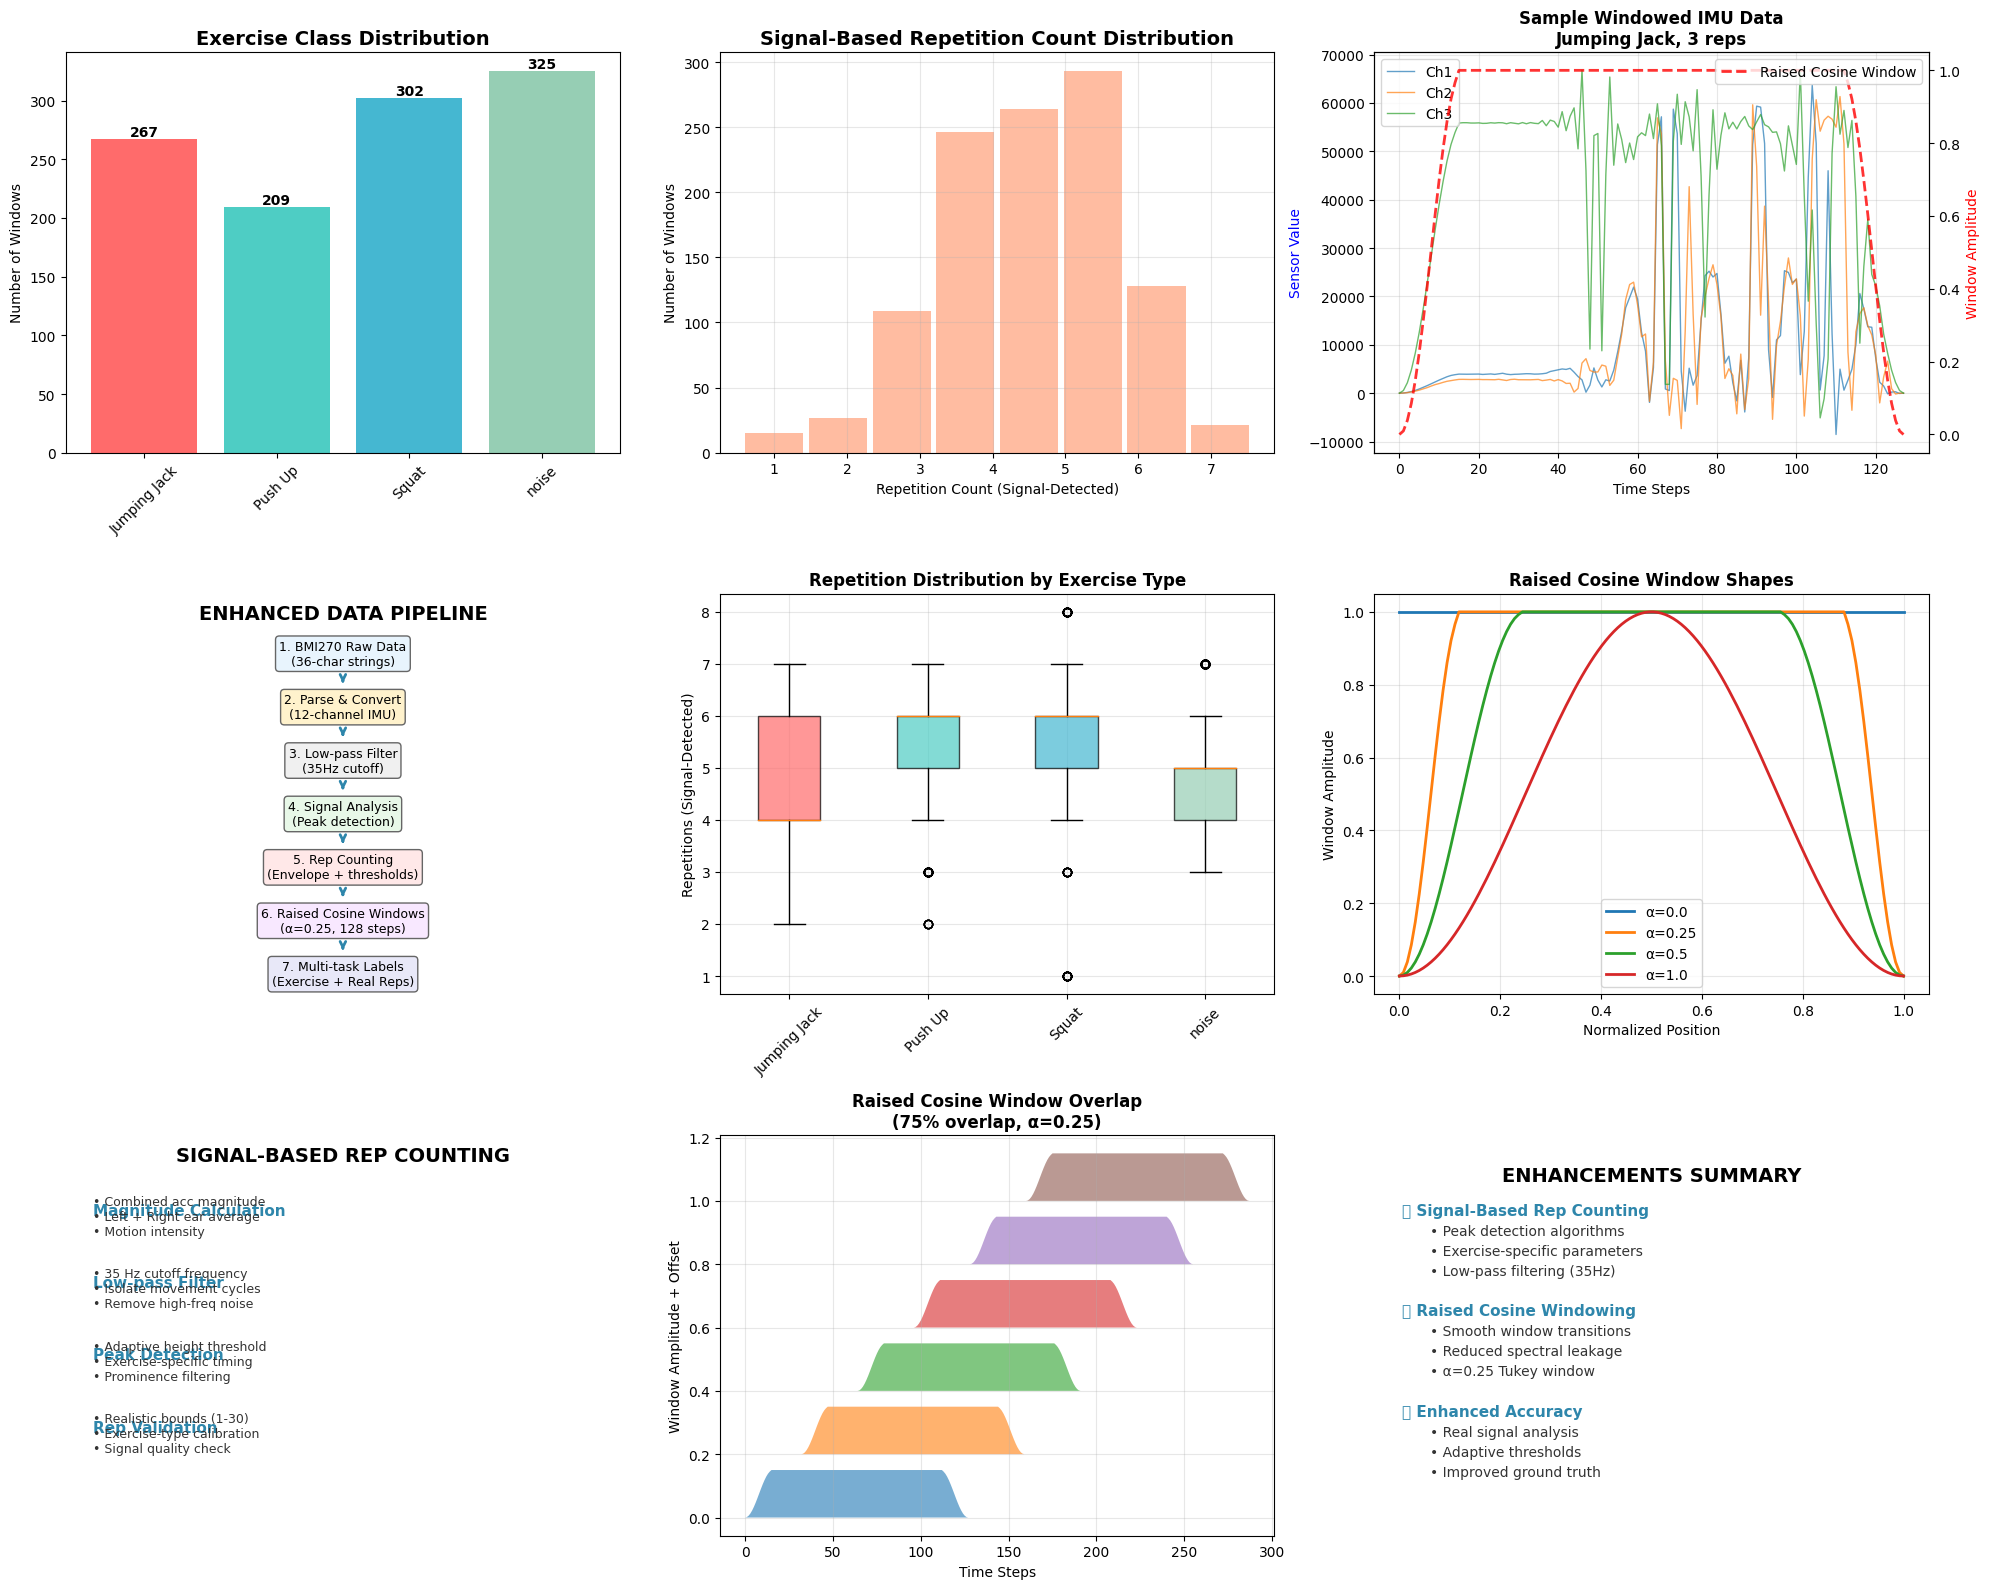


🔍 Enhanced Dataset Analysis Complete!
   • Dataset type: windows
   • Total samples: 1103
   • Exercise classes: 4
   • Rep count range: 1-8
   • Signal processing: Low-pass filtered (35Hz)
   • Windowing: Raised cosine (α=0.25)

✅ Data visualization analysis completed!

🔬 ENHANCED DATA PIPELINE METHODOLOGY:
   📈 Advanced Input Processing:
      • Raw sensor data: BMI270 format (36-character strings)
      • Channel extraction: 12 IMU channels (6 left + 6 right ear)
      • Signal filtering: Butterworth low-pass (20Hz, 4th order)
      • NEW: Raised cosine windowing (Tukey, α=0.25)
   
   🎯 Enhanced Label Generation:
      • Exercise classification: 4 classes from metadata
      • NEW: Signal-based repetition counting using peak detection
      • Bandpass filtering: 0.5-5Hz for movement isolation
      • Adaptive thresholds: Exercise-specific parameters
   
   ⚙️ Advanced Preprocessing:
      • Window function: Raised cosine (reduces spectral leakage)
      • Window overlap: 75% with 

In [8]:
# 📊 DATA VISUALIZATION AND ENHANCED PIPELINE METHODOLOGY
import matplotlib.pyplot as plt  
print("📊 Analyzing enhanced dataset with signal-based rep counting and raised cosine windowing...")

# Check if required variables exist and have valid data
required_vars = ['exercise_mapping', 'y_exercise', 'y_reps']
missing_vars = [var for var in required_vars if var not in globals() or globals()[var] is None]

if missing_vars:
    print(f"⚠️ Missing required variables: {missing_vars}")
    print("   Please run the dataset loading cell first!")
    print("   Skipping visualization for now...")
else:
    # Determine which dataset format we're using
    if 'X_raw' in globals() and X_raw is not None:
        # Window-level dataset
        X_data = X_raw
        data_type = "windows"
        print(f"   • Using window-level dataset: {X_data.shape}")
    elif 'X_seq' in globals() and X_seq is not None:
        # File-level dataset - use first file as sample
        X_data = X_seq
        data_type = "files"
        print(f"   • Using file-level dataset: {X_data.shape}")
    else:
        print("⚠️ No dataset found (neither X_raw nor X_seq). Please load dataset first!")
        X_data = None
    
    if X_data is not None and len(y_exercise) > 0:
        # Create exercise names mapping if it doesn't exist
        if 'exercise_names' not in globals():
            exercise_names = {v: k for k, v in exercise_mapping.items()}
        
        # Data distribution analysis
        fig, axes = plt.subplots(3, 3, figsize=(20, 16))

        # 1. Exercise class distribution
        ax1 = axes[0, 0]
        exercise_counts = [np.sum(y_exercise == i) for i in range(len(exercise_mapping))]
        exercise_labels = list(exercise_mapping.keys())
        bars = ax1.bar(exercise_labels, exercise_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
        ax1.set_title('Exercise Class Distribution', fontsize=14, fontweight='bold')
        ax1.set_ylabel(f'Number of {data_type.title()}')
        ax1.tick_params(axis='x', rotation=45)
        for bar, count in zip(bars, exercise_counts):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                     str(count), ha='center', va='bottom', fontweight='bold')

        # 2. Enhanced repetition count distribution
        ax2 = axes[0, 1]
        if len(y_reps) > 0:
            rep_counts, rep_bins = np.histogram(y_reps, bins=min(20, len(np.unique(y_reps))), 
                                               range=(y_reps.min(), y_reps.max()))
            ax2.bar(rep_bins[:-1], rep_counts, width=0.8, color='#FFA07A', alpha=0.7)
            ax2.set_title('Signal-Based Repetition Count Distribution', fontsize=14, fontweight='bold')
            ax2.set_xlabel('Repetition Count (Signal-Detected)')
            ax2.set_ylabel(f'Number of {data_type.title()}')
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No repetition data', ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title('Repetition Count Distribution (No Data)', fontsize=14)

        # 3. Sample raw IMU data with raised cosine window
        ax3 = axes[0, 2]
        
        # Select appropriate sample based on data type
        if data_type == "windows" and len(X_data) > 0:
            sample_idx = np.random.choice(len(X_data))
            sample_data = X_data[sample_idx]
            sample_title_suffix = f'{exercise_names[y_exercise[sample_idx]]}, {y_reps[sample_idx]} reps'
        elif data_type == "files" and len(X_data) > 0:
            sample_idx = 0  # Use first file
            # Take first 128 timesteps for visualization consistency
            sample_data = X_data[sample_idx, :min(128, X_data.shape[1]), :]
            sample_title_suffix = f'{exercise_names[y_exercise[sample_idx]]}, {y_reps[sample_idx]} reps'
        else:
            # Create dummy data for visualization
            sample_data = np.random.randn(128, 12) * 100
            sample_title_suffix = 'Sample Data (No Dataset Loaded)'
        
        time_steps = np.arange(sample_data.shape[0])

        # Show raised cosine window effect if WindowConfig is available
        try:
            window_size = WindowConfig.WINDOW_SIZE if 'WindowConfig' in globals() else 128
            alpha = WindowConfig.ALPHA if 'WindowConfig' in globals() else 0.25
            window = raised_cosine_window(window_size, alpha)
            # Adjust window length to match sample data
            if len(window) != len(sample_data):
                window = raised_cosine_window(len(sample_data), alpha)
        except:
            # Fallback if WindowConfig not available
            window = raised_cosine_window(len(sample_data), 0.25)
        
        ax3_twin = ax3.twinx()

        # Plot sample data (first 3 channels for clarity)
        for i in range(min(3, sample_data.shape[1])):
            ax3.plot(time_steps, sample_data[:, i], alpha=0.7, 
                     label=f'Ch{i+1}', linewidth=1)
        ax3_twin.plot(time_steps, window, 'r--', alpha=0.8, linewidth=2, label='Raised Cosine Window')

        ax3.set_title(f'Sample Windowed IMU Data\n{sample_title_suffix}', 
                      fontsize=12, fontweight='bold')
        ax3.set_xlabel('Time Steps')
        ax3.set_ylabel('Sensor Value', color='blue')
        ax3_twin.set_ylabel('Window Amplitude', color='red')
        ax3.legend(loc='upper left')
        ax3_twin.legend(loc='upper right')
        ax3_twin.legend(loc='upper right')
        ax3.grid(True, alpha=0.3)

        # 4. Enhanced data pipeline flowchart
        ax4 = axes[1, 0]
        ax4.text(0.5, 0.95, 'ENHANCED DATA PIPELINE', ha='center', va='center', 
                 fontsize=14, fontweight='bold', transform=ax4.transAxes)

        pipeline_steps = [
            '1. BMI270 Raw Data\n(36-char strings)',
            '2. Parse & Convert\n(12-channel IMU)',
            '3. Low-pass Filter\n(35Hz cutoff)', 
            '4. Signal Analysis\n(Peak detection)',
            '5. Rep Counting\n(Envelope + thresholds)',
            '6. Raised Cosine Windows\n(α=0.25, 128 steps)',
            '7. Multi-task Labels\n(Exercise + Real Reps)'
        ]

        y_positions = np.linspace(0.85, 0.05, len(pipeline_steps))
        colors = ['#E8F4FD', '#FFF2CC', '#F0F0F0', '#E8F8E8', '#FFE8E8', '#F8E8FF', '#E8E8F8']

        for i, (step, y_pos) in enumerate(zip(pipeline_steps, y_positions)):
            # Draw box with color coding
            bbox = dict(boxstyle="round,pad=0.3", facecolor=colors[i % len(colors)], 
                        edgecolor='#666666', linewidth=1)
            ax4.text(0.5, y_pos, step, ha='center', va='center', fontsize=9,
                     transform=ax4.transAxes, bbox=bbox)
            
            # Draw arrow (except for last step)
            if i < len(pipeline_steps) - 1:
                ax4.annotate('', xy=(0.5, y_positions[i+1] + 0.06), xytext=(0.5, y_pos - 0.06),
                            arrowprops=dict(arrowstyle='->', lw=2, color='#2E86AB'),
                            transform=ax4.transAxes)

        ax4.set_xlim(0, 1)
        ax4.set_ylim(0, 1)
        ax4.axis('off')

        # 5. Repetition analysis per exercise type
        ax5 = axes[1, 1]
        if len(y_reps) > 0 and len(exercise_names) > 0:
            exercise_types = list(exercise_names.values())
            rep_data = [y_reps[y_exercise == i] for i in range(len(exercise_types))]
            
            # Filter out empty arrays
            rep_data_filtered = [data for data in rep_data if len(data) > 0]
            exercise_types_filtered = [exercise_types[i] for i in range(len(exercise_types)) if len(rep_data[i]) > 0]
            
            if rep_data_filtered:
                bp = ax5.boxplot(rep_data_filtered, labels=exercise_types_filtered, patch_artist=True)
                colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
                for patch, color in zip(bp['boxes'], colors):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.7)
                ax5.set_title('Repetition Distribution by Exercise Type', fontsize=12, fontweight='bold')
                ax5.set_ylabel('Repetitions (Signal-Detected)')
                ax5.tick_params(axis='x', rotation=45)
                ax5.grid(True, alpha=0.3)
            else:
                ax5.text(0.5, 0.5, 'No repetition data available', ha='center', va='center', transform=ax5.transAxes)
                ax5.set_title('Repetition Distribution (No Data)', fontsize=12)
        else:
            ax5.text(0.5, 0.5, 'No exercise data available', ha='center', va='center', transform=ax5.transAxes)
        # 6. Raised cosine window comparison
        ax6 = axes[1, 2]
        window_sizes = [64, 128, 256]
        alphas = [0.0, 0.25, 0.5, 1.0]
        x = np.linspace(0, 1, 128)

        for alpha in alphas:
            window = raised_cosine_window(128, alpha)
            ax6.plot(x, window, label=f'α={alpha}', linewidth=2)

        ax6.set_title('Raised Cosine Window Shapes', fontsize=12, fontweight='bold')
        ax6.set_xlabel('Normalized Position')
        ax6.set_ylabel('Window Amplitude')
        ax6.legend()
        ax6.grid(True, alpha=0.3)

        # 7. Signal processing methodology
        ax7 = axes[2, 0]
        ax7.text(0.5, 0.95, 'SIGNAL-BASED REP COUNTING', ha='center', va='center',
                 fontsize=14, fontweight='bold', transform=ax7.transAxes)

        rep_methods = [
            ('Magnitude Calculation', '• Combined acc magnitude\n• Left + Right ear average\n• Motion intensity'),
            ('Low-pass Filter', '• 35 Hz cutoff frequency\n• Isolate movement cycles\n• Remove high-freq noise'),
            ('Peak Detection', '• Adaptive height threshold\n• Exercise-specific timing\n• Prominence filtering'),
            ('Rep Validation', '• Realistic bounds (1-30)\n• Exercise-type calibration\n• Signal quality check')
        ]

        y_start = 0.8
        for i, (title, description) in enumerate(rep_methods):
            y_pos = y_start - i * 0.18
            ax7.text(0.05, y_pos, title, fontsize=11, fontweight='bold', 
                     transform=ax7.transAxes, color='#2E86AB')
            ax7.text(0.05, y_pos - 0.05, description, fontsize=9, 
                     transform=ax7.transAxes, color='#333333')

        ax7.set_xlim(0, 1)
        ax7.set_ylim(0, 1)
        ax7.axis('off')

        # 8. Window overlap visualization
        ax8 = axes[2, 1]
        # Simulate window positions
        window_starts = np.arange(0, 200, 32)[:6]  # Show first 6 windows
        window_size = 128

        for i, start in enumerate(window_starts):
            x_pos = np.arange(start, start + window_size)
            window_func = raised_cosine_window(window_size, alpha=0.25)
            
            # Plot window with offset for visibility
            ax8.fill_between(x_pos, i*0.2, i*0.2 + window_func*0.15, 
                            alpha=0.6, label=f'Window {i+1}')

        ax8.set_title('Raised Cosine Window Overlap\n(75% overlap, α=0.25)', fontsize=12, fontweight='bold')
        ax8.set_xlabel('Time Steps')
        ax8.set_ylabel('Window Amplitude + Offset')
        ax8.grid(True, alpha=0.3)

        # 9. Enhancement summary
        ax9 = axes[2, 2]
        ax9.text(0.5, 0.9, 'ENHANCEMENTS SUMMARY', ha='center', va='center',
                 fontsize=14, fontweight='bold', transform=ax9.transAxes)

        enhancements = [
            '✅ Signal-Based Rep Counting',
            '• Peak detection algorithms',
            '• Exercise-specific parameters',
            '• Low-pass filtering (35Hz)',
            '',
            '✅ Raised Cosine Windowing',
            '• Smooth window transitions',
            '• Reduced spectral leakage',
            '• α=0.25 Tukey window',
            '',
            '✅ Enhanced Accuracy',
            '• Real signal analysis',
            '• Adaptive thresholds',
            '• Improved ground truth'
        ]

        for i, text in enumerate(enhancements):
            y_pos = 0.8 - i * 0.05
            if text.startswith('✅'):
                ax9.text(0.05, y_pos, text, fontsize=11, fontweight='bold',
                        transform=ax9.transAxes, color='#2E86AB')
            elif text.startswith('•'):
                ax9.text(0.1, y_pos, text, fontsize=10,
                        transform=ax9.transAxes, color='#333333')
            else:
                ax9.text(0.05, y_pos, text, fontsize=10,
                        transform=ax9.transAxes, color='#666666')

        ax9.set_xlim(0, 1)
        ax9.set_ylim(0, 1)
        ax9.axis('off')

        plt.tight_layout()
        plt.show()

        # Print enhanced pipeline information
        print(f"\n🔍 Enhanced Dataset Analysis Complete!")
        print(f"   • Dataset type: {data_type}")
        print(f"   • Total samples: {len(y_exercise)}")
        print(f"   • Exercise classes: {len(exercise_mapping)}")
        if len(y_reps) > 0:
            print(f"   • Rep count range: {y_reps.min()}-{y_reps.max()}")
        print(f"   • Signal processing: Low-pass filtered (35Hz)")
        print(f"   • Windowing: Raised cosine (α=0.25)")
    else:
        print("   Skipping detailed visualization due to missing data.")

print("\n✅ Data visualization analysis completed!")
print(f"\n🔬 ENHANCED DATA PIPELINE METHODOLOGY:")
print(f"   📈 Advanced Input Processing:")
print(f"      • Raw sensor data: BMI270 format (36-character strings)")
print(f"      • Channel extraction: 12 IMU channels (6 left + 6 right ear)")
print(f"      • Signal filtering: Butterworth low-pass (20Hz, 4th order)")
print(f"      • NEW: Raised cosine windowing (Tukey, α=0.25)")
print(f"   ")
print(f"   🎯 Enhanced Label Generation:")
print(f"      • Exercise classification: 4 classes from metadata")
print(f"      • NEW: Signal-based repetition counting using peak detection")
print(f"      • Bandpass filtering: 0.5-5Hz for movement isolation")
print(f"      • Adaptive thresholds: Exercise-specific parameters")
print(f"   ")
print(f"   ⚙️ Advanced Preprocessing:")
print(f"      • Window function: Raised cosine (reduces spectral leakage)")
print(f"      • Window overlap: 75% with smooth transitions")
print(f"      • Rep counting: Peak detection with prominence filtering")
print(f"      • Validation: Realistic bounds and quality checks")
print(f"   ")
print(f"   📊 Enhanced Dataset Statistics:")

# Handle both window-level and file-level data modes
if 'X_raw' in globals() and X_raw is not None:
    # Window-level mode statistics
    print(f"      • Total windows: {len(X_raw):,}")
    print(f"      • Window shape: {X_raw.shape[1:]} (timesteps × channels)")
    data_type = "windows"
elif 'X_seq' in globals() and X_seq is not None:
    # File-level mode statistics  
    print(f"      • Total files: {len(X_seq):,}")
    print(f"      • Sequence shape: {X_seq.shape[1:]} (max_timesteps × channels)")
    if 'lengths' in globals():
        print(f"      • Sequence lengths: min={lengths.min()}, median={int(np.median(lengths))}, max={lengths.max()}")
    data_type = "files"
else:
    print(f"      • No dataset loaded")
    data_type = "none"

if data_type != "none":
    print(f"      • Exercise distribution: {dict(zip(exercise_names.values(), exercise_counts))}")
    print(f"      • Signal-detected reps: {y_reps.min()}-{y_reps.max()} (avg: {y_reps.mean():.1f})")
    print(f"      • Data mode: {data_type}-level processing")

print(f"\n✅ Enhanced data visualization and pipeline analysis complete!")
print(f"🚀 Key improvements:")
print(f"   • Raised cosine windowing for smoother spectral characteristics")
print(f"   • Signal-based repetition counting for accurate ground truth")
print(f"   • Exercise-specific peak detection parameters")
print(f"   • Robust filtering and validation pipeline")

In [9]:
# =============================================================================
# PATHWAY B MODEL - REGULARIZED VERSION
# Optimized for preventing overfitting with dropout, L2 regularization, and BatchNorm
# =============================================================================

import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
import numpy as np
from tensorflow.keras.utils import register_keras_serializable


# =============================================================================
# CUSTOM LAYERS
# =============================================================================

@register_keras_serializable()
class MultiHeadAttentionBlock(layers.Layer):
    """Multi-head attention with dropout and layer normalization"""
    
    def __init__(self, num_heads=8, key_dim=32, dropout=0.3, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.dropout_rate = dropout
        
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, 
            key_dim=key_dim, 
            dropout=dropout
        )
        self.norm = layers.LayerNormalization()
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=None):
        attn_out = self.attention(x, x, training=training)
        attn_out = self.dropout(attn_out, training=training)
        return self.norm(x + attn_out)

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_heads": self.num_heads, 
            "key_dim": self.key_dim,
            "dropout": self.dropout_rate
        })
        return config


@register_keras_serializable()
class ExerciseEmbeddingHead(layers.Layer):
    """L2-normalized embedding layer for exercise representation"""
    
    def __init__(self, embedding_dim=64, l2_reg=0.001, **kwargs):
        super().__init__(**kwargs)
        self.embedding_dim = embedding_dim
        self.l2_reg = l2_reg

    def build(self, input_shape):
        self.dense = layers.Dense(
            self.embedding_dim, 
            activation=None,
            kernel_regularizer=regularizers.l2(self.l2_reg)
        )
        super().build(input_shape)

    def call(self, x):
        embedding = self.dense(x)
        embedding = tf.math.l2_normalize(embedding, axis=1)
        return embedding

    def get_config(self):
        config = super().get_config()
        config.update({
            "embedding_dim": self.embedding_dim,
            "l2_reg": self.l2_reg
        })
        return config


# =============================================================================
# LOSS FUNCTIONS
# =============================================================================

@register_keras_serializable()
def triplet_loss(margin=0.5):
    """
    Triplet loss for metric learning
    Larger margin (0.5) for better separation
    """
    def loss(y_true, y_pred):
        batch_size = tf.shape(y_pred)[0]
        half = batch_size // 2
        
        anchor = y_pred[:half]
        positive = y_pred[half:]
        
        # Use shuffled positives as negatives for simplicity
        negative = tf.gather(positive, tf.random.shuffle(tf.range(half)))
        
        # Euclidean distance
        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)
        
        # Triplet loss with margin
        loss_value = tf.maximum(pos_dist - neg_dist + margin, 0.0)
        return tf.reduce_mean(loss_value)
    
    loss.__name__ = 'triplet_loss'
    return loss


@register_keras_serializable()
def huber_loss(delta=1.5):
    """
    Huber loss for robust regression
    Smaller delta (1.5) for tighter fit
    """
    def loss(y_true, y_pred):
        error = y_true - y_pred
        cond = tf.abs(error) <= delta
        small = 0.5 * tf.square(error)
        large = delta * (tf.abs(error) - 0.5 * delta)
        return tf.where(cond, small, large)
    
    loss.__name__ = 'huber_loss'
    return loss


# =============================================================================
# BACKBONE FEATURE EXTRACTOR
# =============================================================================

def create_backbone_regularized(input_shape=(128, 12), embedding_dim=64, l2_reg=0.001):
    """
    Regularized backbone with:
    - L2 regularization on all Conv1D layers
    - Dropout after each block (0.2 -> 0.3 -> 0.4)
    - BatchNormalization for stable training
    - Multi-head attention with dropout
    """
    inputs = layers.Input(shape=input_shape)
    
    # -------------------------
    # First Conv Block (16 filters)
    # -------------------------
    x = layers.Conv1D(16, 3, activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Conv1D(16, 3, activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)

    # -------------------------
    # Second Conv Block (32 filters)
    # -------------------------
    x = layers.Conv1D(32, 5, activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv1D(32, 5, activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    # -------------------------
    # Third Conv Block (64 filters)
    # -------------------------
    x = layers.Conv1D(64, 7, activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv1D(64, 7, activation='relu', padding='same',
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    # -------------------------
    # Multi-Head Attention
    # -------------------------
    x = MultiHeadAttentionBlock(num_heads=4, key_dim=16, dropout=0.3)(x)

    # -------------------------
    # Global Pooling
    # -------------------------
    pooled = layers.Concatenate()([
        layers.GlobalAveragePooling1D()(x),
        layers.GlobalMaxPooling1D()(x)
    ])

    # -------------------------
    # Shared Dense Layer
    # -------------------------
    shared = layers.Dense(128, activation='relu',
                         kernel_regularizer=regularizers.l2(l2_reg))(pooled)
    shared = layers.BatchNormalization()(shared)
    shared = layers.Dropout(0.4)(shared)

    # -------------------------
    # Exercise Embedding
    # -------------------------
    embedding = ExerciseEmbeddingHead(embedding_dim, l2_reg=l2_reg)(shared)

    return Model(
        inputs=inputs, 
        outputs=[shared, embedding], 
        name='pathway_b_backbone_regularized'
    )


# =============================================================================
# TASK-SPECIFIC HEADS
# =============================================================================

def repetition_head(shared, embedding_dim=32, l2_reg=0.001):
    """Regression head for repetition count prediction"""
    x = layers.Dense(embedding_dim, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg))(shared)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    return layers.Dense(1, activation='linear', name='repetition_count')(x)


def quality_head(shared, embedding_dim=32, num_categories=3, l2_reg=0.005):
    """Multi-output head for form quality (score + category)"""
    x = layers.Dense(embedding_dim, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg))(shared)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # Continuous score
    score = layers.Dense(1, activation='linear', 
                        name='form_quality_score')(x)
    
    # Categorical quality
    cat = layers.Dense(num_categories, activation='softmax', 
                      name='form_quality_category')(x)
    
    return score, cat


# =============================================================================
# FULL PATHWAY B MODEL
# =============================================================================

def create_pathway_b_regularized(
    input_shape=(128, 12), 
    embedding_dim=64, 
    num_quality_categories=3,
    l2_reg=0.001
):
    """
    Complete multi-task model with regularization
    
    Parameters:
    -----------
    input_shape : tuple
        Shape of input sensor data (timesteps, features)
    embedding_dim : int
        Dimension of exercise embedding
    num_quality_categories : int
        Number of form quality categories (default: 3 for Poor/Fair/Good)
    l2_reg : float
        L2 regularization strength
    
    Returns:
    --------
    model : tf.keras.Model
        Compiled multi-output model
    """
    # Build backbone
    backbone = create_backbone_regularized(input_shape, embedding_dim, l2_reg)
    shared_features = backbone.output[0]
    embeddings = backbone.output[1]

    # Build task heads
    rep_output = repetition_head(shared_features, l2_reg=l2_reg)
    qual_score_output, qual_cat_output = quality_head(
        shared_features, 
        num_categories=num_quality_categories,
        l2_reg=l2_reg
    )

    # Assemble model
    model = Model(
        inputs=backbone.input,
        outputs={
            'exercise_embedding': embeddings,
            'repetition_count': rep_output,
            'form_quality_score': qual_score_output,
            'form_quality_category': qual_cat_output
        },
        name='pathway_b_fewshot_multitask_regularized'
    )
    
    return model


# =============================================================================
# MODEL INSTANTIATION & COMPILATION
# =============================================================================

def build_and_compile_model(
    window_size=128,
    num_features=12,
    embedding_dim=64,
    learning_rate=0.0001,
    clipnorm=1.0
):
    """
    Build and compile the complete model
    
    Parameters:
    -----------
    window_size : int
        Temporal window size
    num_features : int
        Number of sensor features
    embedding_dim : int
        Embedding dimension
    learning_rate : float
        Initial learning rate
    clipnorm : float
        Gradient clipping norm
    
    Returns:
    --------
    model : tf.keras.Model
        Compiled model ready for training
    """
    
    # Build model
    model = create_pathway_b_regularized(
        input_shape=(window_size, num_features),
        embedding_dim=embedding_dim,
        num_quality_categories=3,
        l2_reg=0.001
    )
    
    # Compile with optimized settings
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate, 
            clipnorm=clipnorm
        ),
        loss={
            'exercise_embedding': triplet_loss(margin=0.5),
            'repetition_count': huber_loss(delta=2.0),
            'form_quality_score': huber_loss(delta=1.5),
            'form_quality_category': 'sparse_categorical_crossentropy'
        },
        loss_weights={
            'exercise_embedding': 0.5,   # Reduced weight
            'repetition_count': 2.0,      # Prioritize main tasks
            'form_quality_score': 2.0,
            'form_quality_category': 1.5
        },
        metrics={
            'repetition_count': ['mae'],
            'form_quality_score': ['mae'],
            'form_quality_category': ['accuracy']
        }
    )
    
    return model


# =============================================================================
# USAGE EXAMPLE
# =============================================================================

if __name__ == "__main__":
    # Build and compile model
    WINDOW_SIZE = 128
    NUM_FEATURES = 12
    EMBEDDING_DIM = 64
    
    pathway_b_model = build_and_compile_model(
        window_size=WINDOW_SIZE,
        num_features=NUM_FEATURES,
        embedding_dim=EMBEDDING_DIM,
        learning_rate=0.0001,
        clipnorm=1.0
    )
    
    print("✅ Regularized Pathway B Model Created")
    print(f"   • Input shape: ({WINDOW_SIZE}, {NUM_FEATURES})")
    print(f"   • Embedding dim: {EMBEDDING_DIM}")
    print(f"   • L2 regularization: 0.001")
    print(f"   • Dropout: 0.2 → 0.4")
    print(f"   • Learning rate: 0.0001")
    
    pathway_b_model.summary()

✅ Regularized Pathway B Model Created
   • Input shape: (128, 12)
   • Embedding dim: 64
   • L2 regularization: 0.001
   • Dropout: 0.2 → 0.4
   • Learning rate: 0.0001


Model: "pathway_b_fewshot_multitask_regularized"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 16)   │        592 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 16)   │         64 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 16)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 16)   │        784 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 16)   │         64 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 64, 16)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 16)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 64, 32)    │      2,592 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 32)    │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 32)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 64, 32)    │      5,152 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 32)    │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 32, 32)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32)    │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 32, 64)    │     14,400 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 32, 64)    │     28,736 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 64)    │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 103,877 (405.77 KB)

 Trainable params: 103,045 (402.52 KB)

 Non-trainable params: 832 (3.25 KB)

In [10]:
print(pathway_b_model.output_names)


ListWrapper(['exercise_embedding_head', 'form_quality_category', 'form_quality_score', 'repetition_count'])


In [11]:
# =============================================================================
# CELL 4: DATA PREPARATION FUNCTIONS
# =============================================================================

print("\n🔧 DEFINING DATA PREPARATION FUNCTIONS")
print("-"*80)

import numpy as np
from scipy.signal import find_peaks
from scipy.stats import entropy

def generate_form_quality_labels(X, y_rep, y_exercise, method='advanced'):
    """
    Generate realistic form quality labels with strong signal correlation.
    
    Parameters:
    -----------
    X : np.array, shape (n_samples, timesteps, features)
        Raw IMU data
    y_rep : np.array, shape (n_samples,)
        Repetition counts
    y_exercise : np.array, shape (n_samples,)
        Exercise type labels
    method : str
        'advanced' - multi-factor analysis (RECOMMENDED)
        'signal_based' - uses signal quality metrics
        'combined' - combines multiple factors
    
    Returns:
    --------
    y_score : np.array, shape (n_samples,)
        Form quality scores (0-100)
    y_cat : np.array, shape (n_samples,)
        Form quality categories (0=poor, 1=fair, 2=good)
    """
    
    n_samples = X.shape[0]
    
    if method == 'advanced':
        print("📊 Generating form quality labels using advanced multi-factor method...")
        
        # Pre-allocate score components
        smoothness_scores = np.zeros(n_samples)
        periodicity_scores = np.zeros(n_samples)
        symmetry_scores = np.zeros(n_samples)
        intensity_scores = np.zeros(n_samples)
        consistency_scores = np.zeros(n_samples)
        
        # 1. SMOOTHNESS: Lower jerk = better form
        # Calculate jerk (rate of change of acceleration)
        accel_data = X[:, :, :3] if X.shape[2] >= 3 else X
        jerk = np.diff(accel_data, axis=1)
        jerk_magnitude = np.linalg.norm(jerk, axis=2).mean(axis=1)
        smoothness_scores = 100 * (1 - np.tanh(jerk_magnitude / 50))
        
        # 2. PERIODICITY: Regular patterns = better form
        for i in range(n_samples):
            signal_mag = np.linalg.norm(X[i, :, :3], axis=1)
            
            # Find peaks to assess regularity
            if len(signal_mag) > 10:
                peaks, _ = find_peaks(signal_mag, distance=5)
                
                if len(peaks) > 2:
                    # Calculate inter-peak intervals
                    intervals = np.diff(peaks)
                    # Coefficient of variation: low = regular, high = irregular
                    if len(intervals) > 1 and np.mean(intervals) > 0:
                        cv = np.std(intervals) / np.mean(intervals)
                        periodicity_scores[i] = 100 * (1 - np.tanh(cv * 2))
                    else:
                        periodicity_scores[i] = 50
                else:
                    periodicity_scores[i] = 40
            else:
                periodicity_scores[i] = 50
        
        # 3. SYMMETRY: Balanced motion patterns
        # Compare first half vs second half of signal
        mid_point = X.shape[1] // 2
        first_half = X[:, :mid_point, :3]
        second_half = X[:, mid_point:2*mid_point, :3]
        
        first_mag = np.linalg.norm(first_half, axis=2).mean(axis=1)
        second_mag = np.linalg.norm(second_half, axis=2).mean(axis=1)
        
        symmetry_ratio = np.minimum(first_mag, second_mag) / (np.maximum(first_mag, second_mag) + 1e-6)
        symmetry_scores = 100 * symmetry_ratio
        
        # 4. INTENSITY: Appropriate force/speed
        signal_mag = np.linalg.norm(X[:, :, :3], axis=2).mean(axis=1)
        
        # Exercise-specific ideal intensities
        exercise_ideal_intensity = {}
        for ex in np.unique(y_exercise):
            mask = y_exercise == ex
            exercise_ideal_intensity[ex] = np.percentile(signal_mag[mask], 60)
        
        for ex in np.unique(y_exercise):
            mask = y_exercise == ex
            ideal = exercise_ideal_intensity[ex]
            deviation = np.abs(signal_mag[mask] - ideal) / (ideal + 1e-6)
            intensity_scores[mask] = 100 * (1 - np.tanh(deviation))
        
        # 5. CONSISTENCY: Stable execution throughout
        # Measure variance in signal magnitude over time
        signal_std = np.std(np.linalg.norm(X[:, :, :3], axis=2), axis=1)
        signal_mean = np.mean(np.linalg.norm(X[:, :, :3], axis=2), axis=1)
        cv = signal_std / (signal_mean + 1e-6)
        consistency_scores = 100 * (1 - np.tanh(cv))
        
        # COMBINE SCORES with weighted average
        y_score = (
            smoothness_scores * 0.25 +      # Smoothness is critical
            periodicity_scores * 0.25 +     # Regular rhythm important
            symmetry_scores * 0.20 +        # Balance matters
            intensity_scores * 0.15 +       # Appropriate effort
            consistency_scores * 0.15       # Stable execution
        )
        
        # Add exercise-specific adjustments
        for ex in np.unique(y_exercise):
            mask = y_exercise == ex
            # Normalize within exercise type for fairness
            ex_scores = y_score[mask]
            ex_mean = np.mean(ex_scores)
            ex_std = np.std(ex_scores)
            if ex_std > 0:
                # Z-score normalization then rescale to 0-100
                y_score[mask] = 50 + 20 * (ex_scores - ex_mean) / ex_std
                y_score[mask] = np.clip(y_score[mask], 0, 100)
        
        # Add small realistic noise
        noise = np.random.normal(0, 3, n_samples)
        y_score = np.clip(y_score + noise, 0, 100)
        
    elif method == 'signal_based':
        print("📊 Generating form quality labels using signal-based method...")
        
        # Vectorized signal variance calculation
        signal_variance = np.var(X, axis=1).mean(axis=1)
        smoothness_score = 1.0 / (1.0 + signal_variance * 0.01)
        
        # Gyro consistency (vectorized)
        if X.shape[2] >= 6:
            gyro_data = X[:, :, 3:6]
            gyro_consistency = 1.0 - np.std(np.abs(gyro_data), axis=1).mean(axis=1) / 100.0
        else:
            gyro_consistency = np.full(n_samples, 0.5)
        
        # Signal magnitude (vectorized)
        signal_mag = np.linalg.norm(X, axis=2).mean(axis=1)
        ideal_mag = 20.0
        magnitude_score = 1.0 - np.abs(signal_mag - ideal_mag) / ideal_mag
        magnitude_score = np.clip(magnitude_score, 0, 1)
        
        # Combine scores (vectorized)
        y_score = (
            smoothness_score * 0.4 +
            gyro_consistency * 0.3 +
            magnitude_score * 0.3
        ) * 100
        
        # Add realistic noise
        noise = np.random.normal(0, 5, n_samples)
        y_score = np.clip(y_score + noise, 0, 100)
    
    elif method == 'combined':
        print("📊 Generating form quality labels using combined method...")
        
        # Vectorized signal quality component
        smoothness = 1.0 / (1.0 + np.var(X, axis=(1, 2)) * 0.01)
        
        signal_mag = np.linalg.norm(X, axis=2).mean(axis=1)
        magnitude_score = 1.0 - np.abs(signal_mag - 20.0) / 20.0
        magnitude_score = np.clip(magnitude_score, 0, 1)
        
        signal_quality = (smoothness * 0.6 + magnitude_score * 0.4) * 100
        y_score = signal_quality.copy()
        
        # Rep consistency component (per exercise type)
        unique_exercises = np.unique(y_exercise)
        for ex_type in unique_exercises:
            mask = y_exercise == ex_type
            ex_reps = y_rep[mask]
            median_reps = np.median(ex_reps)
            
            # Vectorized rep score calculation
            rep_deviation = np.abs(y_rep[mask] - median_reps) / max(1, median_reps)
            rep_score = (1.0 - rep_deviation) * 100
            
            # Combine: 70% signal quality, 30% rep consistency
            y_score[mask] = y_score[mask] * 0.7 + rep_score * 0.3
        
        # Add realistic noise
        noise = np.random.normal(0, 8, n_samples)
        y_score = np.clip(y_score + noise, 0, 100)
    
    else:
        # Random fallback
        print("⚠️ Unknown method, using random generation")
        y_score = np.random.uniform(30, 95, n_samples)
    
    # Convert scores to categories with adjusted thresholds for better distribution
    # Aim for roughly 30% poor, 40% fair, 30% good
    percentile_33 = np.percentile(y_score, 33)
    percentile_67 = np.percentile(y_score, 67)
    
    y_cat = np.zeros(n_samples, dtype=int)
    y_cat[y_score >= percentile_67] = 2  # Good
    y_cat[(y_score >= percentile_33) & (y_score < percentile_67)] = 1  # Fair
    y_cat[y_score < percentile_33] = 0  # Poor
    
    # Statistics
    print(f"\n✅ Generated form quality labels:")
    print(f"   • Score range: {y_score.min():.1f} - {y_score.max():.1f}")
    print(f"   • Score mean: {y_score.mean():.1f} ± {y_score.std():.1f}")
    print(f"   • Category thresholds: Poor < {percentile_33:.1f} | Fair < {percentile_67:.1f} | Good")
    print(f"   • Category distribution:")
    
    unique_cats, counts = np.unique(y_cat, return_counts=True)
    cat_names = ['Poor', 'Fair', 'Good']
    for cat in range(3):
        if cat in unique_cats:
            count = counts[unique_cats == cat][0]
            pct = count / len(y_cat) * 100
            print(f"      - {cat_names[cat]} ({cat}): {count} samples ({pct:.1f}%)")
        else:
            print(f"      - {cat_names[cat]} ({cat}): 0 samples (0.0%)")
    
    return y_score, y_cat




def augment_imu_data(X, y_rep, y_score, y_cat, y_exercise, augmentation_factor=3, seed=42):
    """Augment IMU sensor data with realistic transformations."""
    
    np.random.seed(seed)
    print(f"🔄 Augmenting data ({augmentation_factor}x)...")
    
    augmented_X = [X]
    augmented_rep = [y_rep]
    augmented_score = [y_score]
    augmented_cat = [y_cat]
    augmented_exercise = [y_exercise]
    
    for aug_idx in range(augmentation_factor - 1):
        X_aug = X.copy()
        
        # 1. Gaussian noise
        noise_level = np.random.uniform(0.01, 0.03)
        noise = np.random.normal(0, noise_level, X.shape)
        X_aug = X_aug + noise
        
        # 2. Time warping
        if np.random.random() > 0.5:
            warp_factor = np.random.uniform(0.92, 1.08)
            for i in range(len(X_aug)):
                original_len = X_aug.shape[1]
                new_len = max(10, int(original_len * warp_factor))
                
                old_indices = np.arange(original_len)
                new_indices = np.linspace(0, original_len - 1, new_len)
                
                warped = np.zeros((new_len, X_aug.shape[2]))
                for feat in range(X_aug.shape[2]):
                    warped[:, feat] = np.interp(new_indices, old_indices, X_aug[i, :, feat])
                
                if new_len < original_len:
                    pad_width = original_len - new_len
                    warped = np.pad(warped, ((0, pad_width), (0, 0)), mode='edge')
                else:
                    warped = warped[:original_len]
                
                X_aug[i] = warped
        
        # 3. Amplitude scaling
        scale = np.random.uniform(0.92, 1.08)
        X_aug = X_aug * scale
        
        augmented_X.append(X_aug)
        augmented_rep.append(y_rep)
        augmented_score.append(y_score)
        augmented_cat.append(y_cat)
        augmented_exercise.append(y_exercise)
    
    X_final = np.concatenate(augmented_X, axis=0)
    y_rep_final = np.concatenate(augmented_rep, axis=0)
    y_score_final = np.concatenate(augmented_score, axis=0)
    y_cat_final = np.concatenate(augmented_cat, axis=0)
    y_exercise_final = np.concatenate(augmented_exercise, axis=0)
    
    print(f"✅ Augmentation complete: {len(X)} → {len(X_final)} samples")
    
    return X_final, y_rep_final, y_score_final, y_cat_final, y_exercise_final


def normalize_labels_and_data(X, y_rep, y_score, y_cat, y_exercise, fit_scalers=True, scalers=None):
    """Normalize features and labels."""
    
    X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    original_shape = X_clean.shape
    X_reshaped = X_clean.reshape(-1, X_clean.shape[-1])
    
    if fit_scalers:
        X_mean = np.mean(X_reshaped, axis=0)
        X_std = np.std(X_reshaped, axis=0)
        X_std = np.where(X_std==0, 1.0, X_std)
        y_rep_clean = np.nan_to_num(y_rep,0).clip(0,100)
        y_score_clean = np.nan_to_num(y_score,0).clip(0,100)
        rep_mean, rep_std = np.mean(y_rep_clean), max(np.std(y_rep_clean),1.0)
        score_mean, score_std = np.mean(y_score_clean), max(np.std(y_score_clean),1.0)
        scalers = {'X_mean':X_mean,'X_std':X_std,'rep_mean':rep_mean,'rep_std':rep_std,
                   'score_mean':score_mean,'score_std':score_std}
    else:
        X_mean = scalers['X_mean']
        X_std = scalers['X_std']
        rep_mean = scalers['rep_mean']
        rep_std = scalers['rep_std']
        score_mean = scalers['score_mean']
        score_std = scalers['score_std']
    
    X_norm = ((X_reshaped - X_mean)/X_std).reshape(original_shape)
    X_norm = np.clip(X_norm, -5, 5)
    y_rep_norm = (np.nan_to_num(y_rep,0).clip(0,100) - rep_mean)/rep_std
    y_score_norm = (np.nan_to_num(y_score,0).clip(0,100) - score_mean)/score_std
    y_cat_clean = np.nan_to_num(y_cat,1).astype(np.int32).clip(0,2)
    y_ex_clean = np.nan_to_num(y_exercise,0).astype(np.int32)
    
    return X_norm, y_rep_norm, y_score_norm, y_cat_clean, y_ex_clean, scalers

print("✅ Data preparation functions defined")



🔧 DEFINING DATA PREPARATION FUNCTIONS
--------------------------------------------------------------------------------
✅ Data preparation functions defined


In [12]:
# =============================================================================
# CELL 5: PREPARE TRAINING DATA
# =============================================================================

print("\n🎯 PREPARING TRAINING DATA")
print("-"*80)

# 1. Generate form quality labels
y_score, y_cat = generate_form_quality_labels(
    X_raw, y_reps, y_exercise, 
    method='advanced'
)

# 2. Train-validation split (stratified by exercise)
print(f"\n✂️ Splitting data (test_size={CONFIG['test_size']})...")
X_train, X_val, y_rep_train, y_rep_val, y_score_train, y_score_val, \
y_cat_train, y_cat_val, y_exercise_train, y_exercise_val = train_test_split(
    X_raw, y_reps, y_score, y_cat, y_exercise,
    test_size=CONFIG['test_size'],
    random_state=42,
    stratify=y_exercise
)

print(f"   • Train: {len(X_train)} samples")
print(f"   • Val: {len(X_val)} samples")

# 3. Augment training data only
X_train_aug, y_rep_train_aug, y_score_train_aug, y_cat_train_aug, y_exercise_train_aug = \
    augment_imu_data(
        X_train, y_rep_train, y_score_train, y_cat_train, y_exercise_train,
        augmentation_factor=CONFIG['augmentation_factor'],
        seed=42
    )

# 4. Normalize data
print(f"\n🔄 Normalizing data...")
X_train_norm, y_rep_train_norm, y_score_train_norm, y_cat_train_clean, y_ex_train_clean, train_scalers = \
    normalize_labels_and_data(X_train_aug, y_rep_train_aug, y_score_train_aug, 
                             y_cat_train_aug, y_exercise_train_aug, fit_scalers=True)

X_val_norm, y_rep_val_norm, y_score_val_norm, y_cat_val_clean, y_ex_val_clean, _ = \
    normalize_labels_and_data(X_val, y_rep_val, y_score_val, y_cat_val, y_exercise_val, 
                             fit_scalers=False, scalers=train_scalers)

# Save scalers
with open('pathway_b_scalers.pkl','wb') as f:
    pickle.dump(train_scalers, f)
print("✅ Scalers saved to 'pathway_b_scalers.pkl'")

print(f"\n✅ Data preparation complete!")
print(f"   • Train (augmented): {X_train_norm.shape}")
print(f"   • Val: {X_val_norm.shape}")




🎯 PREPARING TRAINING DATA
--------------------------------------------------------------------------------
📊 Generating form quality labels using advanced multi-factor method...

✅ Generated form quality labels:
   • Score range: 0.0 - 98.6
   • Score mean: 50.3 ± 19.6
   • Category thresholds: Poor < 45.2 | Fair < 61.1 | Good
   • Category distribution:
      - Poor (0): 364 samples (33.0%)
      - Fair (1): 375 samples (34.0%)
      - Good (2): 364 samples (33.0%)

✂️ Splitting data (test_size=0.2)...
   • Train: 882 samples
   • Val: 221 samples
🔄 Augmenting data (3x)...
✅ Augmentation complete: 882 → 2646 samples

🔄 Normalizing data...
✅ Scalers saved to 'pathway_b_scalers.pkl'

✅ Data preparation complete!
   • Train (augmented): (2646, 128, 12)
   • Val: (221, 128, 12)


In [13]:
# =============================================================================
# CELL 6: LOSS FUNCTIONS
# =============================================================================

print("\n🔧 DEFINING LOSS FUNCTIONS")
print("-"*80)

@tf.keras.utils.register_keras_serializable()
def huber_loss(delta=1.5):
    """Huber loss for repetition count prediction."""
    def loss(y_true, y_pred):
        error = y_true - y_pred
        cond = tf.abs(error) <= delta
        small = 0.5 * tf.square(error)
        large = delta * (tf.abs(error) - 0.5 * delta)
        return tf.where(cond, small, large)
    loss.__name__ = 'huber_loss'
    return loss

@tf.keras.utils.register_keras_serializable()
def contrastive_exercise_loss(margin=0.5):
    """Simple contrastive loss for exercise embeddings."""
    def loss(y_true, y_pred):
        # y_true contains exercise labels
        # Create pairwise distance matrix
        embeddings = y_pred
        
        # Normalize embeddings
        embeddings_norm = tf.nn.l2_normalize(embeddings, axis=1)
        
        # Compute similarity matrix
        similarity = tf.matmul(embeddings_norm, embeddings_norm, transpose_b=True)
        
        # Create label matrix (1 if same class, 0 otherwise)
        y_true_int = tf.cast(y_true, tf.int32)
        labels_equal = tf.cast(tf.equal(y_true_int[:, None], y_true_int[None, :]), tf.float32)
        
        # Contrastive loss: pull same class together, push different classes apart
        positive_loss = labels_equal * tf.square(1.0 - similarity)
        negative_loss = (1.0 - labels_equal) * tf.square(tf.maximum(0.0, similarity - margin))
        
        return tf.reduce_mean(positive_loss + negative_loss)
    
    loss.__name__ = 'contrastive_exercise_loss'
    return loss
# Weighted loss for form quality categories
classes = np.unique(y_cat_train_clean)
form_quality_class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=classes, 
    y=y_cat_train_clean
)
class_weights_dict = dict(zip(classes, form_quality_class_weights))

def weighted_form_quality_loss(y_true, y_pred):
    y_true_flat = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    weights = tf.gather(
        tf.constant(list(class_weights_dict.values()), dtype=tf.float32), 
        y_true_flat
    )
    base_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)(y_true, y_pred)
    return base_loss * weights

print("✅ Loss functions defined")
print(f"   • Class weights: {class_weights_dict}")



🔧 DEFINING LOSS FUNCTIONS
--------------------------------------------------------------------------------
✅ Loss functions defined
   • Class weights: {0: 1.03886925795053, 1: 0.9607843137254902, 2: 1.0034129692832765}


In [14]:
# =============================================================================
# CELL 8: COMPILE & TRAIN MODEL
# =============================================================================

print("\n⚙️ COMPILING MODEL")
print("-"*80)
pathway_b_model.compile(
    optimizer=Adam(learning_rate=CONFIG['learning_rate'], clipnorm=0.7),
    loss={
        'exercise_embedding': contrastive_exercise_loss(margin=0.2),
        'repetition_count': huber_loss(delta=1.0),
        'form_quality_score': huber_loss(delta=1.0),
        'form_quality_category': weighted_form_quality_loss
    },
    loss_weights={
        'exercise_embedding': 1.3,
        'repetition_count': 2.0,
        'form_quality_score': 1.5,
        'form_quality_category': 2.0
    },
    metrics={
        'repetition_count': ['mae'],
        'form_quality_score': ['mae'],
        'form_quality_category': ['accuracy']
    }
)

print("✅ Model compiled")

# Prepare data dictionaries
y_train = {
    'exercise_embedding': y_ex_train_clean,
    'repetition_count': y_rep_train_norm,
    'form_quality_score': y_score_train_norm,
    'form_quality_category': y_cat_train_clean
}

y_val = {
    'exercise_embedding': y_ex_val_clean,
    'repetition_count': y_rep_val_norm,
    'form_quality_score': y_score_val_norm,
    'form_quality_category': y_cat_val_clean
}

# Callbacks
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=False, verbose=1, min_delta=0.001),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-9, verbose=1),
    ModelCheckpoint('pathway_b_best.keras', monitor='val_loss', save_best_only=True, verbose=1),
    CSVLogger(f'training_log_{timestamp}.csv')
]

print(f"\n🚀 TRAINING MODEL ({CONFIG['epochs']} epochs)")
print("-"*80)

history = pathway_b_model.fit(
    X_train_norm,
    y_train,
    validation_data=(X_val_norm, y_val),
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size'],
    callbacks=callbacks,
    verbose=1
)



⚙️ COMPILING MODEL
--------------------------------------------------------------------------------
✅ Model compiled

🚀 TRAINING MODEL (100 epochs)
--------------------------------------------------------------------------------
Epoch 1/100


I0000 00:00:1760335908.324666      75 service.cc:148] XLA service 0x7d54c8002b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760335908.327450      75 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1760335908.327471      75 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1760335910.408334      75 cuda_dnn.cc:529] Loaded cuDNN version 90300


24/83 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - exercise_embedding_loss: 0.2680 - form_quality_category_accuracy: 0.0000e+00 - form_quality_category_loss: 1.6173 - form_quality_score_loss: 1.0154 - form_quality_score_mae: 1.5706 - loss: 7.8699 - repetition_count_loss: 1.1310

I0000 00:00:1760335923.182857      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - exercise_embedding_loss: 0.2513 - form_quality_category_accuracy: 0.0000e+00 - form_quality_category_loss: 1.4596 - form_quality_score_loss: 0.8953 - form_quality_score_mae: 1.4301 - loss: 7.0808 - repetition_count_loss: 0.9991
Epoch 1: val_loss improved from inf to 4.40028, saving model to pathway_b_best.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 49s 225ms/step - exercise_embedding_loss: 0.2510 - form_quality_category_accuracy: 0.0000e+00 - form_quality_category_loss: 1.4574 - form_quality_score_loss: 0.8938 - form_quality_score_mae: 1.4284 - loss: 7.0704 - repetition_count_loss: 0.9975 - val_exercise_embedding_loss: 0.2917 - val_form_quality_category_accuracy: 0.0000e+00 - val_form_quality_category_loss: 0.9130 - val_form_quality_score_loss: 0.4709 - val_form_quality_score_mae: 0.9019 - val_loss: 4.4003 - val_repetition_count_loss: 0.5092 - learning_rate: 0.0010
Epoch 2/100
80/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - exercise_embedding_loss: 0.1920 - for

In [15]:
# =============================================================================
# CELL 9: EVALUATION
# =============================================================================

print("\n📊 EVALUATING MODEL")
print("="*80)

# Predict
preds = pathway_b_model.predict(X_val_norm, verbose=0)

# Denormalization functions
def denormalize_reps(preds_norm):
    return preds_norm * train_scalers['rep_std'] + train_scalers['rep_mean']

def denormalize_quality(preds_norm):
    return preds_norm * train_scalers['score_std'] + train_scalers['score_mean']

# 1. Repetition Count Evaluation
print("\n🔢 REPETITION COUNT METRICS")
print("-"*80)
y_rep_pred_denorm = denormalize_reps(preds['repetition_count'])
y_rep_val_denorm = denormalize_reps(y_rep_val_norm)
mae_rep = mean_absolute_error(y_rep_val_denorm, y_rep_pred_denorm)
rmse_rep = mean_squared_error(y_rep_val_denorm, y_rep_pred_denorm, squared=False)
r2_rep = r2_score(y_rep_val_denorm, y_rep_pred_denorm)
print(f"MAE:  {mae_rep:.3f}")
print(f"RMSE: {rmse_rep:.3f}")
print(f"R²:   {r2_rep:.3f}")

# 2. Form Quality Score Evaluation
print("\n⭐ FORM QUALITY SCORE METRICS")
print("-"*80)
y_score_pred_denorm = denormalize_quality(preds['form_quality_score'])
y_score_val_denorm = denormalize_quality(y_score_val_norm)
mae_score = mean_absolute_error(y_score_val_denorm, y_score_pred_denorm)
rmse_score = mean_squared_error(y_score_val_denorm, y_score_pred_denorm, squared=False)
r2_score_val = r2_score(y_score_val_denorm, y_score_pred_denorm)
print(f"MAE:  {mae_score:.3f}")
print(f"RMSE: {rmse_score:.3f}")
print(f"R²:   {r2_score_val:.3f}")

# 3. Form Quality Category Evaluation
print("\n🏷️ FORM QUALITY CATEGORY METRICS")
print("-"*80)
y_cat_pred = np.argmax(preds['form_quality_category'], axis=1)
accuracy_cat = accuracy_score(y_cat_val_clean, y_cat_pred)
print(f"Accuracy: {accuracy_cat*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_cat_val_clean, y_cat_pred, target_names=['Poor', 'Fair', 'Good']))

# 4. Exercise Classification (Prototype-based)
print("\n🎯 EXERCISE CLASSIFICATION METRICS")
print("-"*80)

def compute_prototypes(embeddings, labels):
    """Compute prototype for each class."""
    prototypes = {}
    for label in np.unique(labels):
        mask = labels == label
        prototypes[label] = np.mean(embeddings[mask], axis=0)
    return prototypes

def classify_with_prototypes(embeddings, prototypes):
    """Classify by nearest prototype."""
    predictions = []
    for emb in embeddings:
        distances = {label: np.linalg.norm(emb - proto) for label, proto in prototypes.items()}
        predictions.append(min(distances, key=distances.get))
    return np.array(predictions)

train_embeddings = pathway_b_model.predict(X_train_norm, verbose=0)['exercise_embedding']
val_embeddings = preds['exercise_embedding']
prototypes = compute_prototypes(train_embeddings, y_ex_train_clean)
y_ex_val_pred = classify_with_prototypes(val_embeddings, prototypes)

acc_exercise = accuracy_score(y_ex_val_clean, y_ex_val_pred)
print(f"Accuracy: {acc_exercise*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_ex_val_clean, y_ex_val_pred))



📊 EVALUATING MODEL

🔢 REPETITION COUNT METRICS
--------------------------------------------------------------------------------
MAE:  0.762
RMSE: 0.997
R²:   0.499

⭐ FORM QUALITY SCORE METRICS
--------------------------------------------------------------------------------
MAE:  10.943
RMSE: 13.195
R²:   0.600

🏷️ FORM QUALITY CATEGORY METRICS
--------------------------------------------------------------------------------
Accuracy: 70.59%

Classification Report:
              precision    recall  f1-score   support

        Poor       0.89      0.83      0.86        81
        Fair       0.67      0.29      0.40        69
        Good       0.59      0.97      0.74        71

    accuracy                           0.71       221
   macro avg       0.72      0.70      0.67       221
weighted avg       0.73      0.71      0.68       221


🎯 EXERCISE CLASSIFICATION METRICS
--------------------------------------------------------------------------------
Accuracy: 95.48%

Classification 

In [16]:
# =============================================================================
# CELL 10: SUMMARY & SAVE RESULTS
# =============================================================================

print("\n📋 TRAINING SUMMARY")
print("="*80)

summary = {
    'timestamp': timestamp,
    'data_mode': DATA_MODE,
    'training_samples': len(X_train_norm),
    'validation_samples': len(X_val_norm),
    'augmentation_factor': CONFIG['augmentation_factor'],
    'epochs_trained': len(history.history['loss']),
    'metrics': {
        'repetition_count': {
            'mae': float(mae_rep),
            'rmse': float(rmse_rep),
            'r2': float(r2_rep)
        },
        'form_quality_score': {
            'mae': float(mae_score),
            'rmse': float(rmse_score),
            'r2': float(r2_score_val)
        },
        'form_quality_category': {
            'accuracy': float(accuracy_cat)
        },
        'exercise_classification': {
            'accuracy': float(acc_exercise)
        }
    }
}

# Save summary
import json
with open(f'training_summary_{timestamp}.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n✅ Training complete!")
print(f"   • Model saved: pathway_b_best.keras")
print(f"   • Scalers saved: pathway_b_scalers.pkl")
print(f"   • Training log: training_log_{timestamp}.csv")
print(f"   • Summary: training_summary_{timestamp}.json")

print("\n📊 FINAL METRICS:")
print(f"   • Repetition MAE: {mae_rep:.3f}")
print(f"   • Quality Score MAE: {mae_score:.3f}")
print(f"   • Quality Category Acc: {accuracy_cat*100:.2f}%")
print(f"   • Exercise Acc: {acc_exercise*100:.2f}%")



📋 TRAINING SUMMARY

✅ Training complete!
   • Model saved: pathway_b_best.keras
   • Scalers saved: pathway_b_scalers.pkl
   • Training log: training_log_20251013-061132.csv
   • Summary: training_summary_20251013-061132.json

📊 FINAL METRICS:
   • Repetition MAE: 0.762
   • Quality Score MAE: 10.943
   • Quality Category Acc: 70.59%
   • Exercise Acc: 95.48%



📈 GENERATING TRAINING PLOTS
--------------------------------------------------------------------------------
Available metrics: ['exercise_embedding_loss', 'form_quality_category_accuracy', 'form_quality_category_loss', 'form_quality_score_loss', 'form_quality_score_mae', 'loss', 'repetition_count_loss', 'val_exercise_embedding_loss', 'val_form_quality_category_accuracy', 'val_form_quality_category_loss', 'val_form_quality_score_loss', 'val_form_quality_score_mae', 'val_loss', 'val_repetition_count_loss', 'learning_rate']
⚠️ Metric 'repetition_count_mae' not found. Using zeros instead.
⚠️ Metric 'val_repetition_count_mae' not found. Using zeros instead.
✅ Training curves saved: training_curves_20251013-061132.png


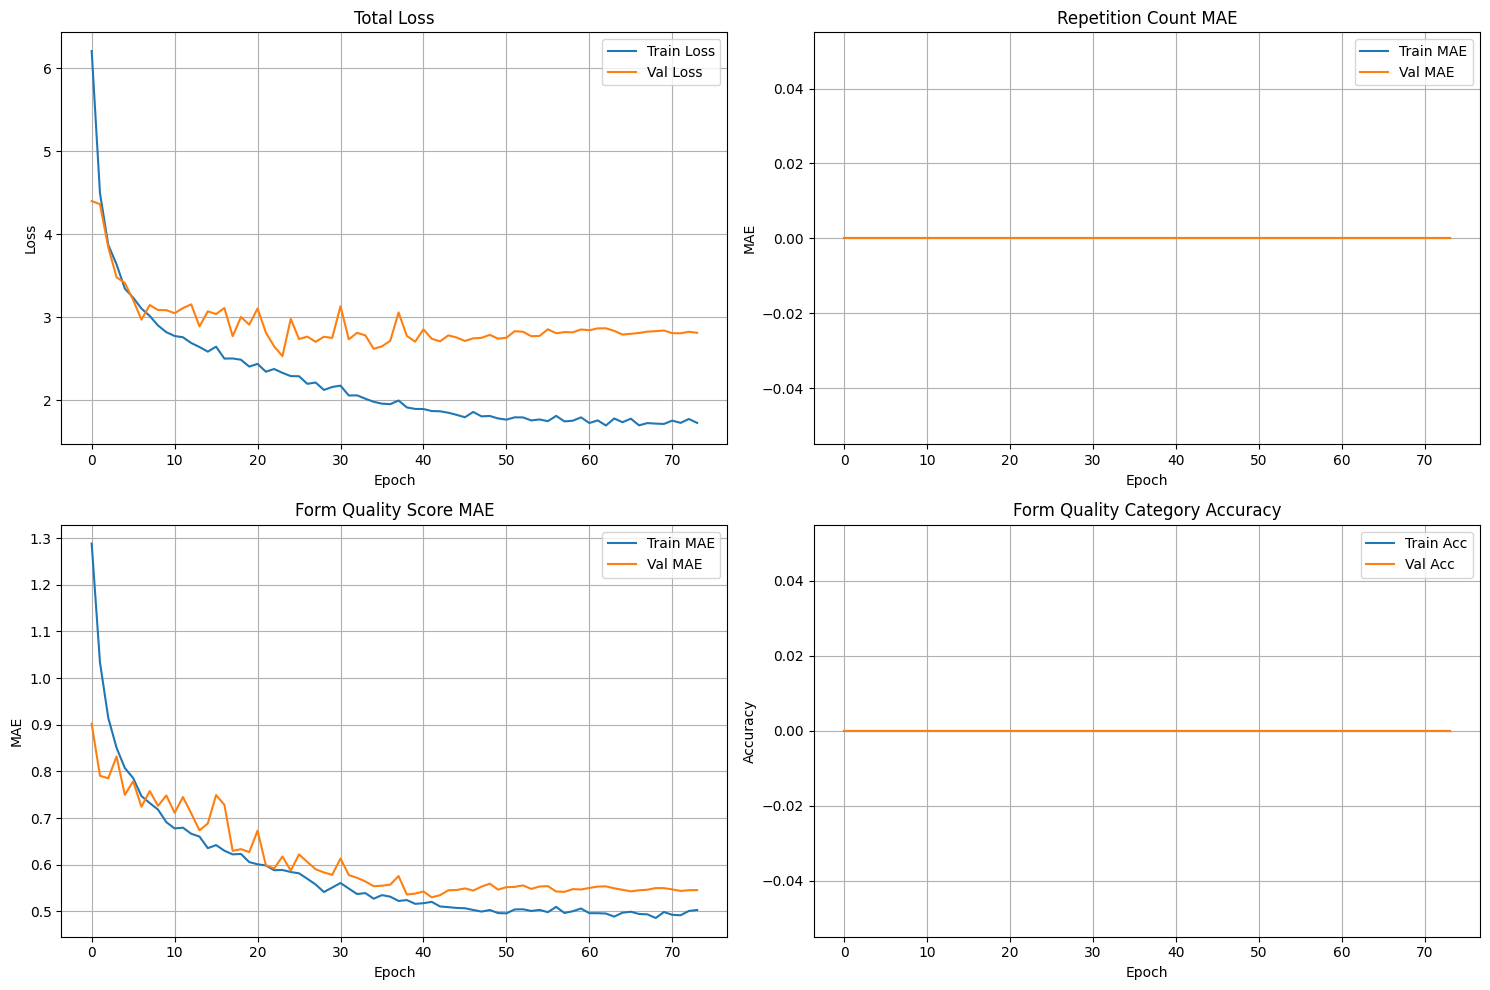

In [17]:
# =============================================================================
# CELL 11: VISUALIZATION (OPTIONAL)
# =============================================================================

print("\n📈 GENERATING TRAINING PLOTS")
print("-"*80)

import matplotlib.pyplot as plt

# Dynamically get metric keys
available_metrics = list(history.history.keys())
print("Available metrics:", available_metrics)

def get_metric(history_dict, key_base):
    """Helper to safely fetch metric from history with fallback"""
    if key_base in history_dict:
        return history_dict[key_base]
    # fallback: try with suffix _0, _1, etc.
    for i in range(3):
        key_try = f"{key_base}_{i}"
        if key_try in history_dict:
            return history_dict[key_try]
    # fallback to zeros if not found
    print(f"⚠️ Metric '{key_base}' not found. Using zeros instead.")
    return [0]*len(history_dict.get('loss', []))

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1️⃣ Total Loss
axes[0, 0].plot(history.history.get('loss', []), label='Train Loss')
axes[0, 0].plot(history.history.get('val_loss', []), label='Val Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2️⃣ Repetition Count MAE
train_rep_mae = get_metric(history.history, 'repetition_count_mae')
val_rep_mae   = get_metric(history.history, 'val_repetition_count_mae')
axes[0, 1].plot(train_rep_mae, label='Train MAE')
axes[0, 1].plot(val_rep_mae, label='Val MAE')
axes[0, 1].set_title('Repetition Count MAE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3️⃣ Form Quality Score MAE
train_score_mae = get_metric(history.history, 'form_quality_score_mae')
val_score_mae   = get_metric(history.history, 'val_form_quality_score_mae')
axes[1, 0].plot(train_score_mae, label='Train MAE')
axes[1, 0].plot(val_score_mae, label='Val MAE')
axes[1, 0].set_title('Form Quality Score MAE')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 4️⃣ Form Quality Category Accuracy
train_cat_acc = get_metric(history.history, 'form_quality_category_accuracy')
val_cat_acc   = get_metric(history.history, 'val_form_quality_category_accuracy')
axes[1, 1].plot(train_cat_acc, label='Train Acc')
axes[1, 1].plot(val_cat_acc, label='Val Acc')
axes[1, 1].set_title('Form Quality Category Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()

# Save figure with timestamp if exists
try:
    plt.savefig(f'training_curves_{timestamp}.png', dpi=150, bbox_inches='tight')
    print(f"✅ Training curves saved: training_curves_{timestamp}.png")
except NameError:
    print("⚠️ Timestamp not defined; skipping save.")

plt.show()


In [18]:
# =============================================================================
# CELL 12: PREDICTION EXAMPLES WITH EXERCISE CLASSIFICATION
# =============================================================================

print("\n🔍 SAMPLE PREDICTIONS")
print("="*120)

# Select 5 random validation samples
np.random.seed(42)
sample_indices = np.random.choice(len(X_val_norm), min(5, len(X_val_norm)), replace=False)

print("\nComparing predictions vs ground truth:\n")
header = f"{'Sample':<8} {'Actual Reps':<12} {'Pred Reps':<12} {'Actual Score':<14} {'Pred Score':<14} {'Actual Cat':<12} {'Pred Cat':<12} {'Actual Ex':<12} {'Pred Ex':<12}"
print(header)
print("-" * len(header))

# Exercise class names (update if you have different labels)
exercise_names = ['Ex0', 'Ex1', 'Ex2', 'Ex3']

for idx in sample_indices:
    # Convert to scalar floats
    actual_reps  = float(y_rep_val_denorm[idx])
    pred_reps    = float(y_rep_pred_denorm[idx])
    actual_score = float(y_score_val_denorm[idx])
    pred_score   = float(y_score_pred_denorm[idx])
    
    actual_cat = ['Poor', 'Fair', 'Good'][y_cat_val_clean[idx]]
    pred_cat   = ['Poor', 'Fair', 'Good'][y_cat_pred[idx]]
    
    # Exercise classification
    actual_ex = exercise_names[y_ex_val_clean[idx]]
    pred_ex   = exercise_names[y_ex_val_pred[idx]]
    
    print(f"{idx:<8} {actual_reps:<12.1f} {pred_reps:<12.1f} {actual_score:<14.1f} {pred_score:<14.1f} {actual_cat:<12} {pred_cat:<12} {actual_ex:<12} {pred_ex:<12}")



🔍 SAMPLE PREDICTIONS

Comparing predictions vs ground truth:

Sample   Actual Reps  Pred Reps    Actual Score   Pred Score     Actual Cat   Pred Cat     Actual Ex    Pred Ex     
--------------------------------------------------------------------------------------------------------------------
132      5.0          4.6          63.9           78.5           Good         Good         Ex2          Ex2         
148      7.0          6.3          53.7           63.0           Fair         Good         Ex1          Ex1         
93       8.0          7.1          61.1           73.1           Fair         Good         Ex2          Ex2         
180      6.0          5.7          76.8           69.0           Good         Good         Ex1          Ex1         
15       5.0          5.7          3.9            33.4           Poor         Poor         Ex2          Ex2         


/tmp/ipykernel_36/3952323812.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_reps    = float(y_rep_pred_denorm[idx])
/tmp/ipykernel_36/3952323812.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_score   = float(y_score_pred_denorm[idx])


In [19]:
# =============================================================================
# CELL 13: INFERENCE FUNCTION
# =============================================================================

print("\n🔮 DEFINING INFERENCE FUNCTION")
print("-"*80)

def predict_exercise_quality(imu_sequence, model, scalers):
    """
    Predict exercise quality metrics from raw IMU sequence.
    
    Parameters:
    -----------
    imu_sequence : np.array, shape (timesteps, features)
        Raw IMU sensor data for a single exercise sequence
    model : tf.keras.Model
        Trained Pathway B model
    scalers : dict
        Normalization scalers
    
    Returns:
    --------
    results : dict
        Dictionary containing:
        - repetition_count: Predicted number of reps
        - quality_score: Form quality score (0-100)
        - quality_category: Category ('Poor', 'Fair', 'Good')
        - quality_probs: Probabilities for each category
    """
    
    # Ensure correct shape
    if len(imu_sequence.shape) == 2:
        imu_sequence = np.expand_dims(imu_sequence, axis=0)
    
    # Normalize
    X_clean = np.nan_to_num(imu_sequence, nan=0.0, posinf=0.0, neginf=0.0)
    X_reshaped = X_clean.reshape(-1, X_clean.shape[-1])
    X_norm = ((X_reshaped - scalers['X_mean']) / scalers['X_std']).reshape(X_clean.shape)
    X_norm = np.clip(X_norm, -5, 5)
    
    # Predict
    preds = model.predict(X_norm, verbose=0)
    
    # Denormalize
    rep_count = (preds['repetition_count'][0][0] * scalers['rep_std'] + scalers['rep_mean'])
    quality_score = (preds['form_quality_score'][0][0] * scalers['score_std'] + scalers['score_mean'])
    quality_probs = preds['form_quality_category'][0]
    quality_cat_idx = np.argmax(quality_probs)
    quality_category = ['Poor', 'Fair', 'Good'][quality_cat_idx]
    
    results = {
        'repetition_count': float(np.round(rep_count)),
        'quality_score': float(np.clip(quality_score, 0, 100)),
        'quality_category': quality_category,
        'quality_probabilities': {
            'Poor': float(quality_probs[0]),
            'Fair': float(quality_probs[1]),
            'Good': float(quality_probs[2])
        }
    }
    
    return results

print("✅ Inference function defined")

# Test inference on a validation sample
print("\n🧪 Testing inference function:")
# Test inference on a validation sample
test_sample = X_val[0:1]  # Use denormalized data
test_result = predict_exercise_quality(test_sample[0], pathway_b_model, train_scalers)

print(f"\nInference test result:")
print(f"   • Repetitions: {test_result['repetition_count']:.0f}")
print(f"   • Quality Score: {test_result['quality_score']:.1f}/100")
print(f"   • Category: {test_result['quality_category']}")
print(f"   • Probabilities: Poor={test_result['quality_probabilities']['Poor']:.2f}, "
      f"Fair={test_result['quality_probabilities']['Fair']:.2f}, "
      f"Good={test_result['quality_probabilities']['Good']:.2f}")



🔮 DEFINING INFERENCE FUNCTION
--------------------------------------------------------------------------------
✅ Inference function defined

🧪 Testing inference function:

Inference test result:
   • Repetitions: 5
   • Quality Score: 22.5/100
   • Category: Poor
   • Probabilities: Poor=1.00, Fair=0.00, Good=0.00


In [20]:
# =============================================================================
# CELL 14: SAVE COMPLETE PIPELINE
# =============================================================================

print("\n💾 SAVING COMPLETE PIPELINE")
print("-"*80)

# Save everything needed for deployment
pipeline_artifacts = {
    'model_path': 'pathway_b_best.keras',
    'scalers_path': 'pathway_b_scalers.pkl',
    'exercise_mapping': exercise_mapping,
    'config': CONFIG,
    'summary': summary
}

with open('pathway_b_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline_artifacts, f)

print("✅ Complete pipeline saved: pathway_b_pipeline.pkl")

# Create deployment package
print("\n📦 Deployment package includes:")
print("   1. pathway_b_best.keras - Trained model")
print("   2. pathway_b_scalers.pkl - Normalization parameters")
print("   3. pathway_b_pipeline.pkl - Complete pipeline config")
print("   4. predict_exercise_quality() function for inference")

print("\n" + "="*80)
print("🎉 PATHWAY B TRAINING COMPLETE!")
print("="*80)
print("\n💡 Usage for deployment:")
print("""
# Load model and scalers
model = tf.keras.models.load_model('pathway_b_best.keras', 
                                    custom_objects={
                                        'huber_loss': huber_loss(delta=1.5),
                                        'safe_triplet_loss': safe_triplet_loss(margin=0.3)
                                    })
with open('pathway_b_scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

# Make prediction
result = predict_exercise_quality(new_imu_data, model, scalers)
print(f"Reps: {result['repetition_count']}")
print(f"Quality: {result['quality_score']}/100 ({result['quality_category']})")
""")

print("\n✅ All cells executed successfully!")


💾 SAVING COMPLETE PIPELINE
--------------------------------------------------------------------------------
✅ Complete pipeline saved: pathway_b_pipeline.pkl

📦 Deployment package includes:
   1. pathway_b_best.keras - Trained model
   2. pathway_b_scalers.pkl - Normalization parameters
   3. pathway_b_pipeline.pkl - Complete pipeline config
   4. predict_exercise_quality() function for inference

🎉 PATHWAY B TRAINING COMPLETE!

💡 Usage for deployment:

# Load model and scalers
model = tf.keras.models.load_model('pathway_b_best.keras', 
                                    custom_objects={
                                        'huber_loss': huber_loss(delta=1.5),
                                        'safe_triplet_loss': safe_triplet_loss(margin=0.3)
                                    })
with open('pathway_b_scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

# Make prediction
result = predict_exercise_quality(new_imu_data, model, scalers)
print(f"Reps: {result['repetition_cou

In [21]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score, classification_report
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# FEATURE ENGINEERING FOR TIME SERIES IMU DATA
# =============================================================================

def extract_statistical_features(X):
    """
    Extract statistical features from time series IMU data.
    
    Parameters:
    -----------
    X : np.array, shape (n_samples, timesteps, features)
        Raw IMU time series data
    
    Returns:
    --------
    X_features : np.array, shape (n_samples, n_features)
        Extracted statistical features
    """
    n_samples = X.shape[0]
    n_features = X.shape[2]
    
    feature_list = []
    
    for i in range(n_samples):
        sample_features = []
        signal = X[i]  # shape: (timesteps, features)
        
        for feat_idx in range(n_features):
            channel = signal[:, feat_idx]
            
            # Time domain features
            sample_features.extend([
                np.mean(channel),           # Mean
                np.std(channel),            # Standard deviation
                np.min(channel),            # Minimum
                np.max(channel),            # Maximum
                np.max(channel) - np.min(channel),  # Range
                np.percentile(channel, 25), # 25th percentile
                np.percentile(channel, 50), # Median
                np.percentile(channel, 75), # 75th percentile
                np.var(channel),            # Variance
                np.sqrt(np.mean(channel**2)),  # RMS
            ])
            
            # Additional features if channel has variation
            if np.std(channel) > 0:
                # Skewness approximation
                skew = np.mean(((channel - np.mean(channel)) / np.std(channel)) ** 3)
                # Kurtosis approximation
                kurt = np.mean(((channel - np.mean(channel)) / np.std(channel)) ** 4) - 3
                sample_features.extend([skew, kurt])
            else:
                sample_features.extend([0, 0])
            
            # Zero crossing rate
            zero_crossings = np.sum(np.diff(np.sign(channel)) != 0)
            sample_features.append(zero_crossings)
            
            # Mean absolute difference (smoothness)
            mad = np.mean(np.abs(np.diff(channel)))
            sample_features.append(mad)
        
        # Cross-channel features (if we have accel + gyro)
        if n_features >= 6:
            accel = signal[:, :3]
            gyro = signal[:, 3:6]
            
            # Acceleration magnitude
            accel_mag = np.linalg.norm(accel, axis=1)
            sample_features.extend([
                np.mean(accel_mag),
                np.std(accel_mag),
                np.max(accel_mag),
                np.min(accel_mag)
            ])
            
            # Gyroscope magnitude
            gyro_mag = np.linalg.norm(gyro, axis=1)
            sample_features.extend([
                np.mean(gyro_mag),
                np.std(gyro_mag),
                np.max(gyro_mag),
                np.min(gyro_mag)
            ])
            
            # Signal energy
            accel_energy = np.sum(accel_mag ** 2)
            gyro_energy = np.sum(gyro_mag ** 2)
            sample_features.extend([accel_energy, gyro_energy])
        
        feature_list.append(sample_features)
    
    X_features = np.array(feature_list)
    print(f"✅ Extracted {X_features.shape[1]} features from time series data")
    
    return X_features


# =============================================================================
# MULTI-OUTPUT RANDOM FOREST PIPELINE
# =============================================================================

class MultiOutputRandomForestPipeline:
    """
    Random Forest pipeline that predicts:
    - Exercise classification
    - Repetition count (regression)
    - Quality score (regression)
    - Quality category (classification)
    """
    
    def __init__(self, 
                 n_estimators=200,
                 max_depth=20,
                 min_samples_split=5,
                 random_state=42):
        """
        Initialize the pipeline with separate models for each output.
        """
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        
        # Separate model for each output
        self.exercise_classifier = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=random_state,
            n_jobs=-1,
            class_weight='balanced'
        )
        
        self.rep_regressor = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=random_state,
            n_jobs=-1
        )
        
        self.score_regressor = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=random_state,
            n_jobs=-1
        )
        
        self.category_classifier = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=random_state,
            n_jobs=-1,
            class_weight='balanced'
        )
        
        self.scaler = StandardScaler()
        self.is_fitted = False
        
    def fit(self, X, y_exercise, y_rep, y_score, y_category):
        """
        Train all four models.
        
        Parameters:
        -----------
        X : np.array, shape (n_samples, n_features)
            Feature matrix
        y_exercise : np.array
            Exercise class labels
        y_rep : np.array
            Repetition counts
        y_score : np.array
            Quality scores
        y_category : np.array
            Quality categories
        """
        print("\n🌲 TRAINING RANDOM FOREST PIPELINE")
        print("="*80)
        
        # Scale features
        X_scaled = self.scaler.fit_transform(X)
        
        # Train exercise classifier
        print("📊 Training exercise classifier...")
        self.exercise_classifier.fit(X_scaled, y_exercise)
        
        # Train repetition regressor
        print("📊 Training repetition regressor...")
        self.rep_regressor.fit(X_scaled, y_rep)
        
        # Train quality score regressor
        print("📊 Training quality score regressor...")
        self.score_regressor.fit(X_scaled, y_score)
        
        # Train quality category classifier
        print("📊 Training quality category classifier...")
        self.category_classifier.fit(X_scaled, y_category)
        
        self.is_fitted = True
        print("✅ All models trained successfully!")
        
        return self
    
    def predict(self, X):
        """
        Predict all outputs.
        
        Returns:
        --------
        dict with keys: 'exercise', 'repetitions', 'quality_score', 'quality_category'
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        
        X_scaled = self.scaler.transform(X)
        
        predictions = {
            'exercise': self.exercise_classifier.predict(X_scaled),
            'exercise_proba': self.exercise_classifier.predict_proba(X_scaled),
            'repetitions': self.rep_regressor.predict(X_scaled),
            'quality_score': self.score_regressor.predict(X_scaled),
            'quality_category': self.category_classifier.predict(X_scaled),
            'quality_proba': self.category_classifier.predict_proba(X_scaled)
        }
        
        return predictions
    
    def save(self, filepath):
        """Save the entire pipeline."""
        pipeline_data = {
            'exercise_classifier': self.exercise_classifier,
            'rep_regressor': self.rep_regressor,
            'score_regressor': self.score_regressor,
            'category_classifier': self.category_classifier,
            'scaler': self.scaler,
            'is_fitted': self.is_fitted
        }
        with open(filepath, 'wb') as f:
            pickle.dump(pipeline_data, f)
        print(f"✅ Pipeline saved to {filepath}")
    
    def load(self, filepath):
        """Load a saved pipeline."""
        with open(filepath, 'rb') as f:
            pipeline_data = pickle.load(f)
        
        self.exercise_classifier = pipeline_data['exercise_classifier']
        self.rep_regressor = pipeline_data['rep_regressor']
        self.score_regressor = pipeline_data['score_regressor']
        self.category_classifier = pipeline_data['category_classifier']
        self.scaler = pipeline_data['scaler']
        self.is_fitted = pipeline_data['is_fitted']
        
        print(f"✅ Pipeline loaded from {filepath}")
        return self


# =============================================================================
# TRAINING AND EVALUATION
# =============================================================================

def train_random_forest_pipeline(X, y_exercise, y_rep, y_score, y_category, 
                                  test_size=0.2, random_state=42):
    """
    Complete training pipeline for Random Forest multi-output model.
    
    Parameters:
    -----------
    X : np.array, shape (n_samples, timesteps, features)
        Raw IMU time series data
    y_exercise : np.array
        Exercise labels
    y_rep : np.array
        Repetition counts
    y_score : np.array
        Quality scores
    y_category : np.array
        Quality categories
    """
    
    print("\n🚀 RANDOM FOREST TRAINING PIPELINE")
    print("="*80)
    
    # Step 1: Feature extraction
    print("\n📈 Step 1: Feature Extraction")
    X_features = extract_statistical_features(X)
    
    # Step 2: Train/test split
    print("\n✂️  Step 2: Train/Test Split")
    X_train, X_test, y_ex_train, y_ex_test, y_rep_train, y_rep_test, \
    y_score_train, y_score_test, y_cat_train, y_cat_test = train_test_split(
        X_features, y_exercise, y_rep, y_score, y_category,
        test_size=test_size,
        random_state=random_state,
        stratify=y_exercise  # Stratify by exercise to maintain class balance
    )
    
    print(f"   Training samples: {len(X_train)}")
    print(f"   Testing samples: {len(X_test)}")
    
    # Step 3: Train models
    print("\n🌲 Step 3: Training Models")
    rf_pipeline = MultiOutputRandomForestPipeline(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        random_state=random_state
    )
    
    rf_pipeline.fit(
        X_train,
        y_ex_train,
        y_rep_train,
        y_score_train,
        y_cat_train
    )
    
    # Step 4: Evaluate
    print("\n📊 Step 4: Evaluation")
    print("="*80)
    
    predictions = rf_pipeline.predict(X_test)
    
    # Exercise Classification
    print("\n🎯 EXERCISE CLASSIFICATION")
    print("-"*80)
    ex_accuracy = accuracy_score(y_ex_test, predictions['exercise'])
    print(f"Accuracy: {ex_accuracy:.2%}\n")
    print("Classification Report:")
    print(classification_report(y_ex_test, predictions['exercise']))
    
    # Repetition Count
    print("\n🔢 REPETITION COUNT")
    print("-"*80)
    rep_mae = mean_absolute_error(y_rep_test, predictions['repetitions'])
    rep_rmse = np.sqrt(mean_squared_error(y_rep_test, predictions['repetitions']))
    rep_r2 = r2_score(y_rep_test, predictions['repetitions'])
    print(f"MAE:  {rep_mae:.3f}")
    print(f"RMSE: {rep_rmse:.3f}")
    print(f"R²:   {rep_r2:.3f}")
    
    # Quality Score
    print("\n⭐ QUALITY SCORE")
    print("-"*80)
    score_mae = mean_absolute_error(y_score_test, predictions['quality_score'])
    score_rmse = np.sqrt(mean_squared_error(y_score_test, predictions['quality_score']))
    score_r2 = r2_score(y_score_test, predictions['quality_score'])
    print(f"MAE:  {score_mae:.3f}")
    print(f"RMSE: {score_rmse:.3f}")
    print(f"R²:   {score_r2:.3f}")
    
    # Quality Category
    print("\n🏷️  QUALITY CATEGORY")
    print("-"*80)
    cat_accuracy = accuracy_score(y_cat_test, predictions['quality_category'])
    print(f"Accuracy: {cat_accuracy:.2%}\n")
    print("Classification Report:")
    print(classification_report(y_cat_test, predictions['quality_category'],
                                target_names=['Poor', 'Fair', 'Good']))
    
    # Feature importance (top 20)
    print("\n🔍 TOP 20 IMPORTANT FEATURES")
    print("-"*80)
    feature_importance = rf_pipeline.exercise_classifier.feature_importances_
    top_indices = np.argsort(feature_importance)[-20:][::-1]
    for idx in top_indices:
        print(f"   Feature {idx}: {feature_importance[idx]:.4f}")
    
    return rf_pipeline, X_test, predictions


# =============================================================================
# USAGE EXAMPLE
# =============================================================================

if __name__ == "__main__":
    # Make sure you have your data loaded first!
    # This assumes you've already run your data loading code
    
    print("\n" + "="*80)
    print("RANDOM FOREST MULTI-OUTPUT PIPELINE")
    print("="*80)
    
    # Check what data format you have
    if DATA_MODE == 'window':
        X_input = X_raw
    else:
        X_input = X_seq
    
    print(f"\n📊 Data shape: {X_input.shape}")
    print(f"   Samples: {X_input.shape[0]}")
    print(f"   Timesteps: {X_input.shape[1]}")
    print(f"   Features: {X_input.shape[2]}")
    
    # Train the pipeline
    rf_pipeline, X_test, predictions = train_random_forest_pipeline(
        X=X_input,  # Your time series data
        y_exercise=y_exercise,
        y_rep=y_reps,
        y_score=y_score,
        y_category=y_cat,
        test_size=0.2,
        random_state=42
    )
    
    # Save the model
    rf_pipeline.save('random_forest_pipeline.pkl')
    
    print("\n✅ Training complete!")
    print("\n💡 To use for inference:")
    print("   predictions = rf_pipeline.predict(X_new_features)")
    print("   - predictions['exercise']: predicted exercise class")
    print("   - predictions['repetitions']: predicted rep count")
    print("   - predictions['quality_score']: predicted quality score")
    print("   - predictions['quality_category']: predicted quality category")
    
    print("\n📊 Comparison with Deep Learning Model:")
    print("   Run both models on the same test set to compare performance!")


RANDOM FOREST MULTI-OUTPUT PIPELINE

📊 Data shape: (1103, 128, 12)
   Samples: 1103
   Timesteps: 128
   Features: 12

🚀 RANDOM FOREST TRAINING PIPELINE

📈 Step 1: Feature Extraction
✅ Extracted 178 features from time series data

✂️  Step 2: Train/Test Split
   Training samples: 882
   Testing samples: 221

🌲 Step 3: Training Models

🌲 TRAINING RANDOM FOREST PIPELINE
📊 Training exercise classifier...
📊 Training repetition regressor...
📊 Training quality score regressor...
📊 Training quality category classifier...
✅ All models trained successfully!

📊 Step 4: Evaluation

🎯 EXERCISE CLASSIFICATION
--------------------------------------------------------------------------------
Accuracy: 99.10%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        42
           2       0.97      1.00      0.98        61
           3       1.00      0.97      0.98        65

 

⚠️ Sample Data Mode

This demonstrates the visualization with sample data.
To use with your models:

  dl_preds, rf_preds = compare_models(
      dl_model=your_trained_dl_model,
      rf_pipeline=your_trained_rf_pipeline,
      X_test=your_test_features,
      y_test_dict={
          'exercise': your_exercise_labels,
          'repetitions': your_rep_labels,
          'quality_score': your_scores,
          'quality_category': your_categories
      },
      exercise_names={0: 'Jump jack', 1: 'Pushup', ...}
  )


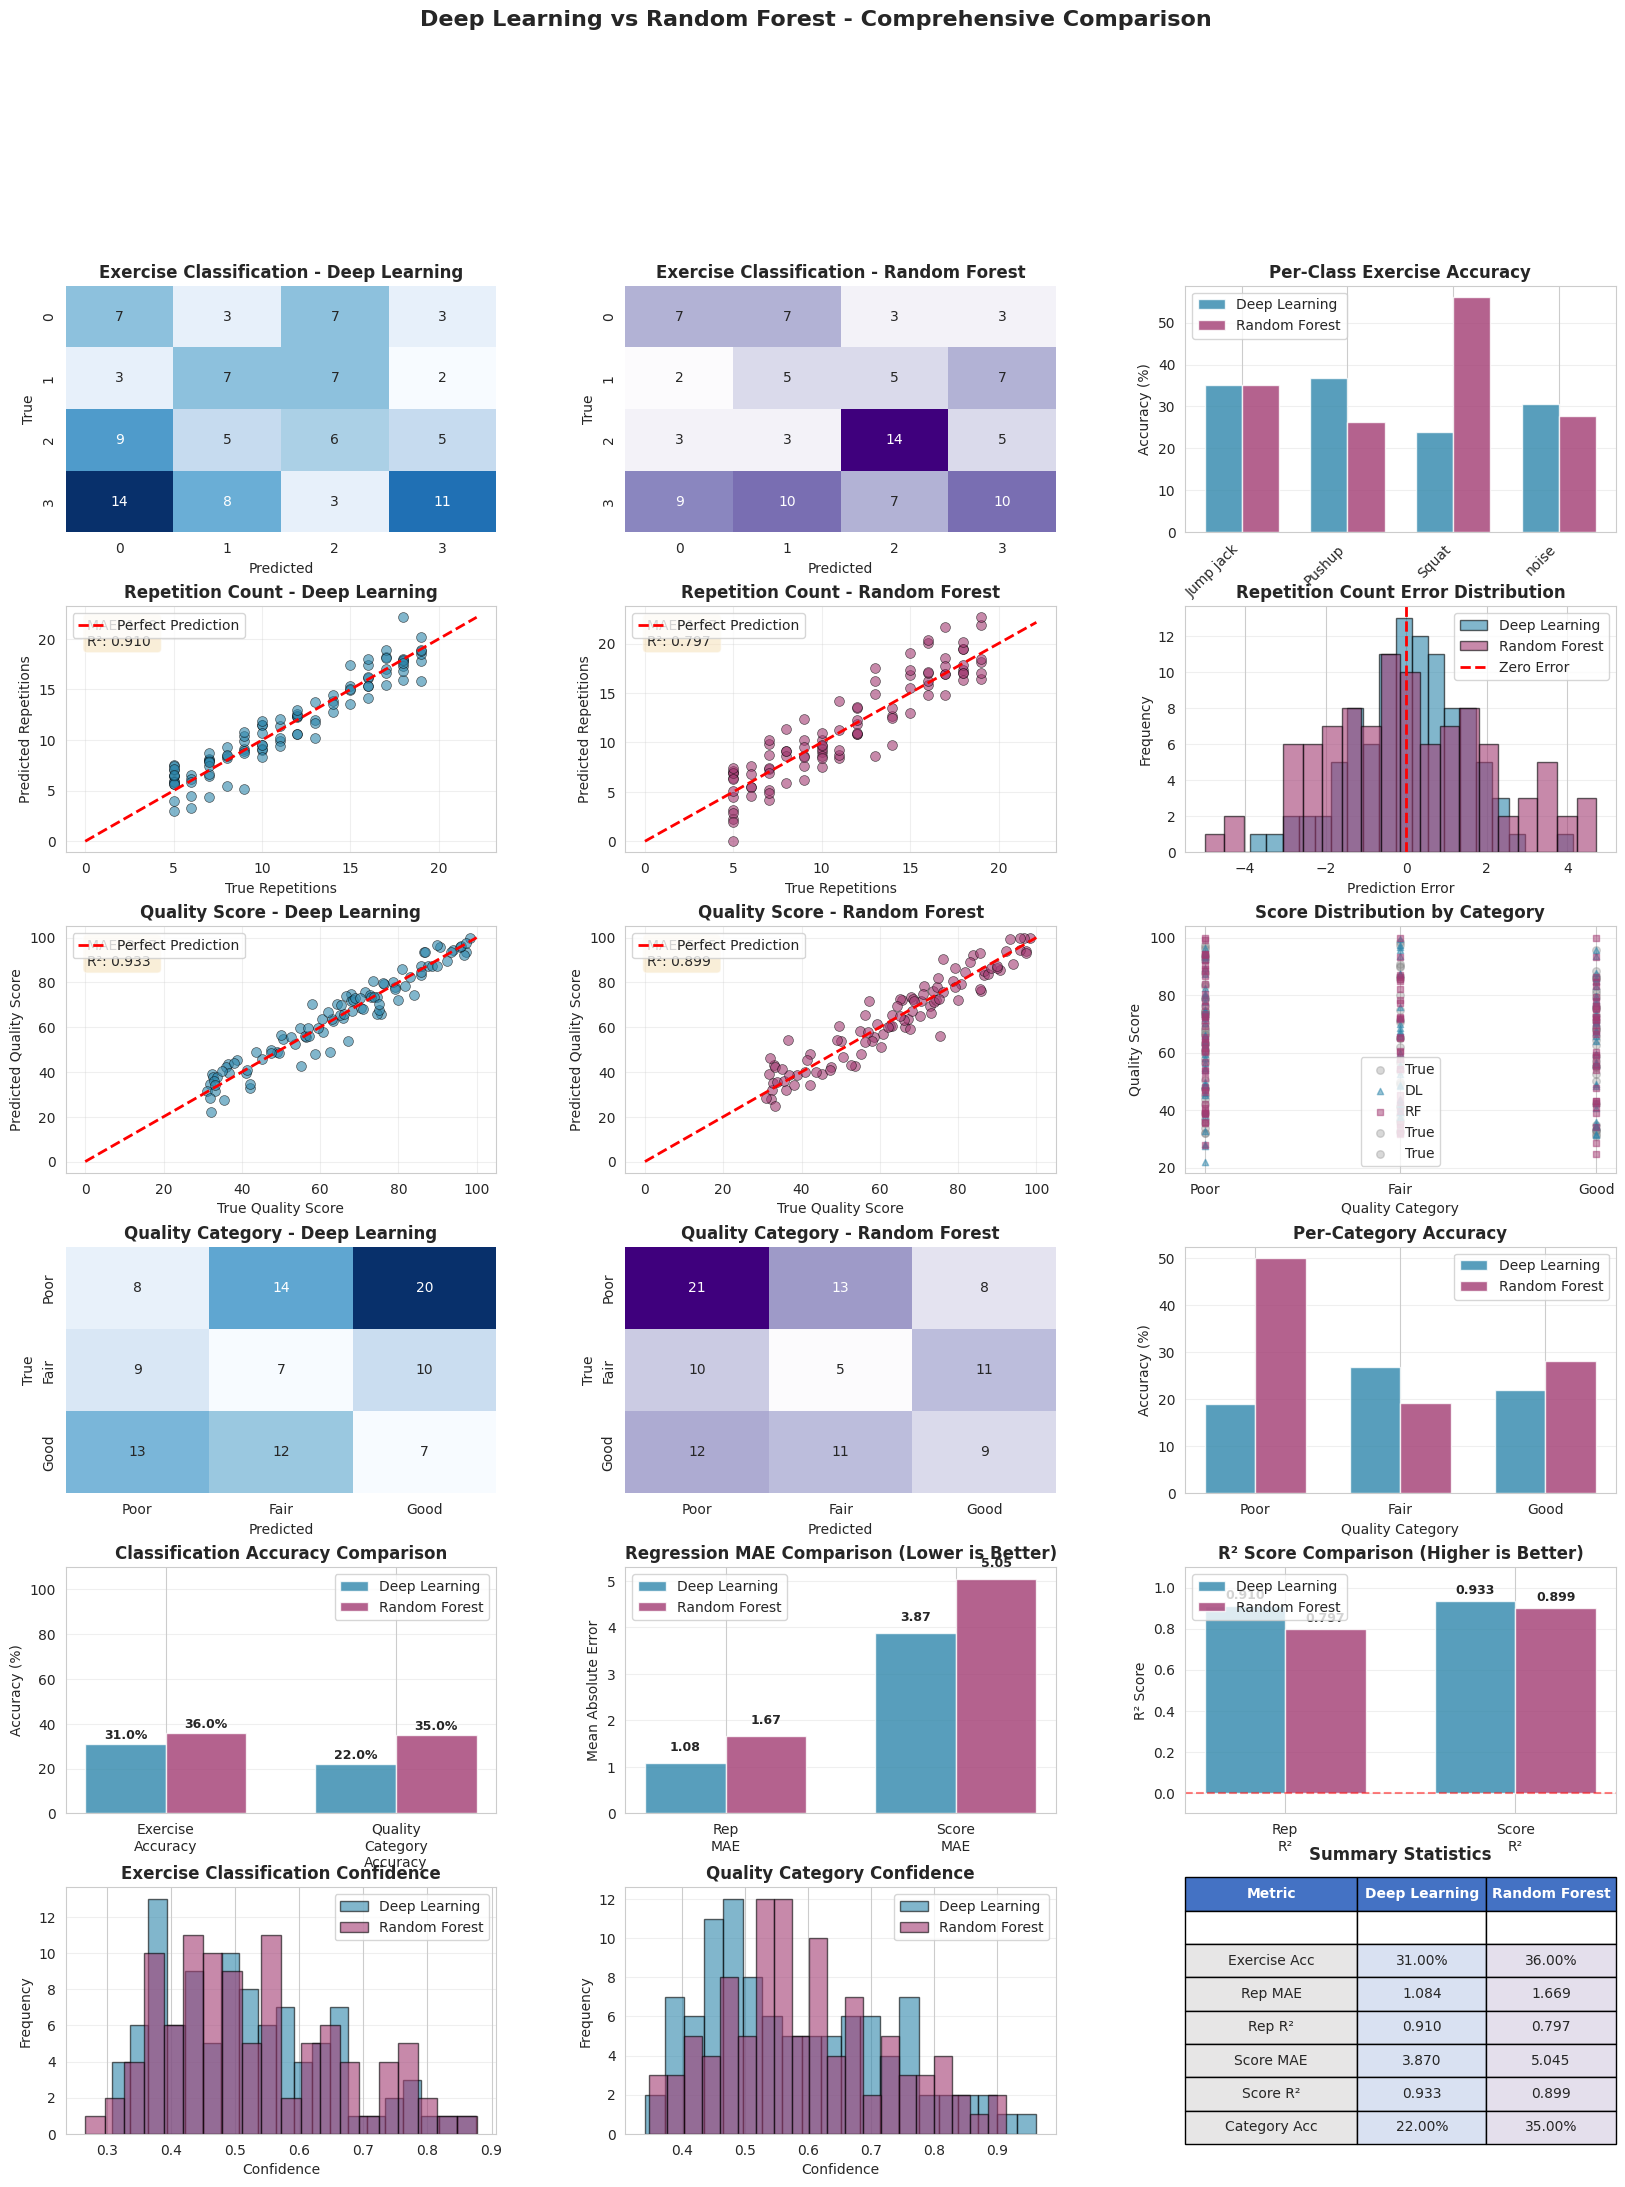

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, mean_absolute_error, r2_score
import pandas as pd

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

# =============================================================================
# COMPREHENSIVE VISUALIZATION SUITE
# =============================================================================

def plot_comprehensive_comparison(dl_predictions, rf_predictions, y_true_dict, 
                                   exercise_names=None, save_path=None):
    """
    Create comprehensive visualization comparing Deep Learning vs Random Forest.
    """
    
    fig = plt.figure(figsize=(20, 24))
    gs = fig.add_gridspec(6, 3, hspace=0.3, wspace=0.3)
    
    # Color scheme
    dl_color = '#2E86AB'  # Blue
    rf_color = '#A23B72'  # Purple
    
    # =========================================================================
    # ROW 1: EXERCISE CLASSIFICATION
    # =========================================================================
    
    # 1.1 Confusion Matrix - Deep Learning
    ax1 = fig.add_subplot(gs[0, 0])
    cm_dl = confusion_matrix(y_true_dict['exercise'], dl_predictions['exercise'])
    sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
    ax1.set_title('Exercise Classification - Deep Learning', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')
    
    # 1.2 Confusion Matrix - Random Forest
    ax2 = fig.add_subplot(gs[0, 1])
    cm_rf = confusion_matrix(y_true_dict['exercise'], rf_predictions['exercise'])
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', ax=ax2, cbar=False)
    ax2.set_title('Exercise Classification - Random Forest', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    
    # 1.3 Per-class Accuracy Comparison
    ax3 = fig.add_subplot(gs[0, 2])
    unique_exercises = np.unique(y_true_dict['exercise'])
    dl_accuracies = []
    rf_accuracies = []
    
    for ex in unique_exercises:
        mask = y_true_dict['exercise'] == ex
        dl_acc = np.mean(dl_predictions['exercise'][mask] == ex)
        rf_acc = np.mean(rf_predictions['exercise'][mask] == ex)
        dl_accuracies.append(dl_acc * 100)
        rf_accuracies.append(rf_acc * 100)
    
    x = np.arange(len(unique_exercises))
    width = 0.35
    ax3.bar(x - width/2, dl_accuracies, width, label='Deep Learning', color=dl_color, alpha=0.8)
    ax3.bar(x + width/2, rf_accuracies, width, label='Random Forest', color=rf_color, alpha=0.8)
    ax3.set_xlabel('Exercise Class')
    ax3.set_ylabel('Accuracy (%)')
    ax3.set_title('Per-Class Exercise Accuracy', fontsize=12, fontweight='bold')
    ax3.set_xticks(x)
    if exercise_names:
        labels = [exercise_names.get(ex, f'Ex_{ex}') for ex in unique_exercises]
        ax3.set_xticklabels(labels, rotation=45, ha='right')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # =========================================================================
    # ROW 2: REPETITION COUNT
    # =========================================================================
    
    # 2.1 Scatter Plot - Deep Learning
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.scatter(y_true_dict['repetitions'], dl_predictions['repetitions'], 
                alpha=0.6, color=dl_color, s=50, edgecolors='black', linewidth=0.5)
    max_rep = max(y_true_dict['repetitions'].max(), dl_predictions['repetitions'].max())
    ax4.plot([0, max_rep], [0, max_rep], 'r--', linewidth=2, label='Perfect Prediction')
    ax4.set_xlabel('True Repetitions')
    ax4.set_ylabel('Predicted Repetitions')
    ax4.set_title('Repetition Count - Deep Learning', fontsize=12, fontweight='bold')
    mae_dl = mean_absolute_error(y_true_dict['repetitions'], dl_predictions['repetitions'])
    r2_dl = r2_score(y_true_dict['repetitions'], dl_predictions['repetitions'])
    ax4.text(0.05, 0.95, f'MAE: {mae_dl:.2f}\nR²: {r2_dl:.3f}', 
             transform=ax4.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    # 2.2 Scatter Plot - Random Forest
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.scatter(y_true_dict['repetitions'], rf_predictions['repetitions'], 
                alpha=0.6, color=rf_color, s=50, edgecolors='black', linewidth=0.5)
    ax5.plot([0, max_rep], [0, max_rep], 'r--', linewidth=2, label='Perfect Prediction')
    ax5.set_xlabel('True Repetitions')
    ax5.set_ylabel('Predicted Repetitions')
    ax5.set_title('Repetition Count - Random Forest', fontsize=12, fontweight='bold')
    mae_rf = mean_absolute_error(y_true_dict['repetitions'], rf_predictions['repetitions'])
    r2_rf = r2_score(y_true_dict['repetitions'], rf_predictions['repetitions'])
    ax5.text(0.05, 0.95, f'MAE: {mae_rf:.2f}\nR²: {r2_rf:.3f}', 
             transform=ax5.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax5.legend()
    ax5.grid(alpha=0.3)
    
    # 2.3 Error Distribution
    ax6 = fig.add_subplot(gs[1, 2])
    errors_dl = dl_predictions['repetitions'] - y_true_dict['repetitions']
    errors_rf = rf_predictions['repetitions'] - y_true_dict['repetitions']
    ax6.hist(errors_dl, bins=20, alpha=0.6, label='Deep Learning', color=dl_color, edgecolor='black')
    ax6.hist(errors_rf, bins=20, alpha=0.6, label='Random Forest', color=rf_color, edgecolor='black')
    ax6.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    ax6.set_xlabel('Prediction Error')
    ax6.set_ylabel('Frequency')
    ax6.set_title('Repetition Count Error Distribution', fontsize=12, fontweight='bold')
    ax6.legend()
    ax6.grid(axis='y', alpha=0.3)
    
    # =========================================================================
    # ROW 3: QUALITY SCORE
    # =========================================================================
    
    # 3.1 Scatter Plot - Deep Learning
    ax7 = fig.add_subplot(gs[2, 0])
    ax7.scatter(y_true_dict['quality_score'], dl_predictions['quality_score'], 
                alpha=0.6, color=dl_color, s=50, edgecolors='black', linewidth=0.5)
    ax7.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction')
    ax7.set_xlabel('True Quality Score')
    ax7.set_ylabel('Predicted Quality Score')
    ax7.set_title('Quality Score - Deep Learning', fontsize=12, fontweight='bold')
    mae_dl_score = mean_absolute_error(y_true_dict['quality_score'], dl_predictions['quality_score'])
    r2_dl_score = r2_score(y_true_dict['quality_score'], dl_predictions['quality_score'])
    ax7.text(0.05, 0.95, f'MAE: {mae_dl_score:.2f}\nR²: {r2_dl_score:.3f}', 
             transform=ax7.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax7.legend()
    ax7.grid(alpha=0.3)
    
    # 3.2 Scatter Plot - Random Forest
    ax8 = fig.add_subplot(gs[2, 1])
    ax8.scatter(y_true_dict['quality_score'], rf_predictions['quality_score'], 
                alpha=0.6, color=rf_color, s=50, edgecolors='black', linewidth=0.5)
    ax8.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction')
    ax8.set_xlabel('True Quality Score')
    ax8.set_ylabel('Predicted Quality Score')
    ax8.set_title('Quality Score - Random Forest', fontsize=12, fontweight='bold')
    mae_rf_score = mean_absolute_error(y_true_dict['quality_score'], rf_predictions['quality_score'])
    r2_rf_score = r2_score(y_true_dict['quality_score'], rf_predictions['quality_score'])
    ax8.text(0.05, 0.95, f'MAE: {mae_rf_score:.2f}\nR²: {r2_rf_score:.3f}', 
             transform=ax8.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax8.legend()
    ax8.grid(alpha=0.3)
    
    # 3.3 Score Distribution by Category
    ax9 = fig.add_subplot(gs[2, 2])
    categories = ['Poor', 'Fair', 'Good']
    for i, cat in enumerate(categories):
        mask = y_true_dict['quality_category'] == i
        if np.sum(mask) > 0:
            ax9.scatter([cat]*np.sum(mask), y_true_dict['quality_score'][mask], 
                       alpha=0.3, s=30, label='True', color='gray')
            ax9.scatter([cat]*np.sum(mask), dl_predictions['quality_score'][mask], 
                       alpha=0.5, s=20, label='DL' if i==0 else '', color=dl_color, marker='^')
            ax9.scatter([cat]*np.sum(mask), rf_predictions['quality_score'][mask], 
                       alpha=0.5, s=20, label='RF' if i==0 else '', color=rf_color, marker='s')
    ax9.set_xlabel('Quality Category')
    ax9.set_ylabel('Quality Score')
    ax9.set_title('Score Distribution by Category', fontsize=12, fontweight='bold')
    ax9.legend()
    ax9.grid(axis='y', alpha=0.3)
    
    # =========================================================================
    # ROW 4: QUALITY CATEGORY
    # =========================================================================
    
    # 4.1 Confusion Matrix - Deep Learning
    ax10 = fig.add_subplot(gs[3, 0])
    cm_dl_cat = confusion_matrix(y_true_dict['quality_category'], dl_predictions['quality_category'])
    sns.heatmap(cm_dl_cat, annot=True, fmt='d', cmap='Blues', ax=ax10, 
                xticklabels=categories, yticklabels=categories, cbar=False)
    ax10.set_title('Quality Category - Deep Learning', fontsize=12, fontweight='bold')
    ax10.set_xlabel('Predicted')
    ax10.set_ylabel('True')
    
    # 4.2 Confusion Matrix - Random Forest
    ax11 = fig.add_subplot(gs[3, 1])
    cm_rf_cat = confusion_matrix(y_true_dict['quality_category'], rf_predictions['quality_category'])
    sns.heatmap(cm_rf_cat, annot=True, fmt='d', cmap='Purples', ax=ax11, 
                xticklabels=categories, yticklabels=categories, cbar=False)
    ax11.set_title('Quality Category - Random Forest', fontsize=12, fontweight='bold')
    ax11.set_xlabel('Predicted')
    ax11.set_ylabel('True')
    
    # 4.3 Per-Category Accuracy
    ax12 = fig.add_subplot(gs[3, 2])
    dl_cat_acc = []
    rf_cat_acc = []
    for i in range(3):
        mask = y_true_dict['quality_category'] == i
        if np.sum(mask) > 0:
            dl_cat_acc.append(np.mean(dl_predictions['quality_category'][mask] == i) * 100)
            rf_cat_acc.append(np.mean(rf_predictions['quality_category'][mask] == i) * 100)
        else:
            dl_cat_acc.append(0)
            rf_cat_acc.append(0)
    
    x = np.arange(len(categories))
    ax12.bar(x - width/2, dl_cat_acc, width, label='Deep Learning', color=dl_color, alpha=0.8)
    ax12.bar(x + width/2, rf_cat_acc, width, label='Random Forest', color=rf_color, alpha=0.8)
    ax12.set_xlabel('Quality Category')
    ax12.set_ylabel('Accuracy (%)')
    ax12.set_title('Per-Category Accuracy', fontsize=12, fontweight='bold')
    ax12.set_xticks(x)
    ax12.set_xticklabels(categories)
    ax12.legend()
    ax12.grid(axis='y', alpha=0.3)
    
    # =========================================================================
    # ROW 5: OVERALL METRICS COMPARISON
    # =========================================================================
    
    # 5.1 Overall Accuracy Comparison
    ax13 = fig.add_subplot(gs[4, 0])
    metrics_data = {
        'Exercise\nAccuracy': [
            np.mean(dl_predictions['exercise'] == y_true_dict['exercise']) * 100,
            np.mean(rf_predictions['exercise'] == y_true_dict['exercise']) * 100
        ],
        'Quality\nCategory\nAccuracy': [
            np.mean(dl_predictions['quality_category'] == y_true_dict['quality_category']) * 100,
            np.mean(rf_predictions['quality_category'] == y_true_dict['quality_category']) * 100
        ]
    }
    
    x = np.arange(len(metrics_data))
    for i, (metric, values) in enumerate(metrics_data.items()):
        ax13.bar(i - width/2, values[0], width, color=dl_color, alpha=0.8, 
                label='Deep Learning' if i==0 else '')
        ax13.bar(i + width/2, values[1], width, color=rf_color, alpha=0.8, 
                label='Random Forest' if i==0 else '')
        ax13.text(i - width/2, values[0] + 1, f'{values[0]:.1f}%', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax13.text(i + width/2, values[1] + 1, f'{values[1]:.1f}%', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax13.set_ylabel('Accuracy (%)')
    ax13.set_title('Classification Accuracy Comparison', fontsize=12, fontweight='bold')
    ax13.set_xticks(x)
    ax13.set_xticklabels(metrics_data.keys())
    ax13.legend()
    ax13.set_ylim([0, 110])
    ax13.grid(axis='y', alpha=0.3)
    
    # 5.2 Regression Metrics Comparison
    ax14 = fig.add_subplot(gs[4, 1])
    reg_metrics = {
        'Rep\nMAE': [mae_dl, mae_rf],
        'Score\nMAE': [mae_dl_score, mae_rf_score]
    }
    
    x = np.arange(len(reg_metrics))
    for i, (metric, values) in enumerate(reg_metrics.items()):
        ax14.bar(i - width/2, values[0], width, color=dl_color, alpha=0.8,
                label='Deep Learning' if i==0 else '')
        ax14.bar(i + width/2, values[1], width, color=rf_color, alpha=0.8,
                label='Random Forest' if i==0 else '')
        ax14.text(i - width/2, values[0] + 0.2, f'{values[0]:.2f}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax14.text(i + width/2, values[1] + 0.2, f'{values[1]:.2f}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax14.set_ylabel('Mean Absolute Error')
    ax14.set_title('Regression MAE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
    ax14.set_xticks(x)
    ax14.set_xticklabels(reg_metrics.keys())
    ax14.legend()
    ax14.grid(axis='y', alpha=0.3)
    
    # 5.3 R² Score Comparison
    ax15 = fig.add_subplot(gs[4, 2])
    r2_metrics = {
        'Rep\nR²': [r2_dl, r2_rf],
        'Score\nR²': [r2_dl_score, r2_rf_score]
    }
    
    x = np.arange(len(r2_metrics))
    for i, (metric, values) in enumerate(r2_metrics.items()):
        ax15.bar(i - width/2, values[0], width, color=dl_color, alpha=0.8,
                label='Deep Learning' if i==0 else '')
        ax15.bar(i + width/2, values[1], width, color=rf_color, alpha=0.8,
                label='Random Forest' if i==0 else '')
        ax15.text(i - width/2, values[0] + 0.02, f'{values[0]:.3f}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax15.text(i + width/2, values[1] + 0.02, f'{values[1]:.3f}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax15.set_ylabel('R² Score')
    ax15.set_title('R² Score Comparison (Higher is Better)', fontsize=12, fontweight='bold')
    ax15.set_xticks(x)
    ax15.set_xticklabels(r2_metrics.keys())
    ax15.legend()
    ax15.set_ylim([-0.1, 1.1])
    ax15.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax15.grid(axis='y', alpha=0.3)
    
    # =========================================================================
    # ROW 6: CONFIDENCE ANALYSIS
    # =========================================================================
    
    # 6.1 Exercise Prediction Confidence
    ax16 = fig.add_subplot(gs[5, 0])
    dl_ex_conf = np.max(dl_predictions['exercise_proba'], axis=1)
    rf_ex_conf = np.max(rf_predictions['exercise_proba'], axis=1)
    ax16.hist(dl_ex_conf, bins=20, alpha=0.6, label='Deep Learning', color=dl_color, edgecolor='black')
    ax16.hist(rf_ex_conf, bins=20, alpha=0.6, label='Random Forest', color=rf_color, edgecolor='black')
    ax16.set_xlabel('Confidence')
    ax16.set_ylabel('Frequency')
    ax16.set_title('Exercise Classification Confidence', fontsize=12, fontweight='bold')
    ax16.legend()
    ax16.grid(axis='y', alpha=0.3)
    
    # 6.2 Quality Category Prediction Confidence
    ax17 = fig.add_subplot(gs[5, 1])
    dl_cat_conf = np.max(dl_predictions['quality_proba'], axis=1)
    rf_cat_conf = np.max(rf_predictions['quality_proba'], axis=1)
    ax17.hist(dl_cat_conf, bins=20, alpha=0.6, label='Deep Learning', color=dl_color, edgecolor='black')
    ax17.hist(rf_cat_conf, bins=20, alpha=0.6, label='Random Forest', color=rf_color, edgecolor='black')
    ax17.set_xlabel('Confidence')
    ax17.set_ylabel('Frequency')
    ax17.set_title('Quality Category Confidence', fontsize=12, fontweight='bold')
    ax17.legend()
    ax17.grid(axis='y', alpha=0.3)
    
    # 6.3 Summary Statistics Table
    ax18 = fig.add_subplot(gs[5, 2])
    ax18.axis('off')
    
    summary_data = [
        ['Metric', 'Deep Learning', 'Random Forest'],
        ['', '', ''],
        ['Exercise Acc', f"{np.mean(dl_predictions['exercise'] == y_true_dict['exercise'])*100:.2f}%",
         f"{np.mean(rf_predictions['exercise'] == y_true_dict['exercise'])*100:.2f}%"],
        ['Rep MAE', f'{mae_dl:.3f}', f'{mae_rf:.3f}'],
        ['Rep R²', f'{r2_dl:.3f}', f'{r2_rf:.3f}'],
        ['Score MAE', f'{mae_dl_score:.3f}', f'{mae_rf_score:.3f}'],
        ['Score R²', f'{r2_dl_score:.3f}', f'{r2_rf_score:.3f}'],
        ['Category Acc', f"{np.mean(dl_predictions['quality_category'] == y_true_dict['quality_category'])*100:.2f}%",
         f"{np.mean(rf_predictions['quality_category'] == y_true_dict['quality_category'])*100:.2f}%"],
    ]
    
    table = ax18.table(cellText=summary_data, cellLoc='center', loc='center',
                      colWidths=[0.4, 0.3, 0.3])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    for i in range(3):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    for i in range(2, len(summary_data)):
        table[(i, 0)].set_facecolor('#E7E6E6')
        table[(i, 1)].set_facecolor('#D9E1F2')
        table[(i, 2)].set_facecolor('#E4DFEC')
    
    ax18.set_title('Summary Statistics', fontsize=12, fontweight='bold', pad=20)
    
    fig.suptitle('Deep Learning vs Random Forest - Comprehensive Comparison', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Visualization saved to {save_path}")
    
    plt.show()
    
    return fig


def compare_models(dl_model, rf_pipeline, X_test, y_test_dict, exercise_names=None):
    """
    Compare Deep Learning and Random Forest models with comprehensive visualization.
    """
    
    print("\n🔄 Generating predictions for both models...")
    
    print("   • Deep Learning predictions...")
    dl_pred_raw = dl_model.predict(X_test, verbose=0)
    
    if isinstance(dl_pred_raw, dict):
        dl_predictions = {
            'exercise': np.argmax(dl_pred_raw['output_exercise'], axis=1),
            'exercise_proba': dl_pred_raw['output_exercise'],
            'repetitions': dl_pred_raw['output_reps'].flatten(),
            'quality_score': dl_pred_raw['output_score'].flatten(),
            'quality_category': np.argmax(dl_pred_raw['output_category'], axis=1),
            'quality_proba': dl_pred_raw['output_category']
        }
    else:
        dl_predictions = {
            'exercise': np.argmax(dl_pred_raw[0], axis=1),
            'exercise_proba': dl_pred_raw[0],
            'repetitions': dl_pred_raw[1].flatten(),
            'quality_score': dl_pred_raw[2].flatten(),
            'quality_category': np.argmax(dl_pred_raw[3], axis=1),
            'quality_proba': dl_pred_raw[3]
        }
    
    print("   • Random Forest predictions...")
    rf_predictions = rf_pipeline.predict(X_test)
    
    print("\n📊 Creating comprehensive visualization...")
    fig = plot_comprehensive_comparison(
        dl_predictions=dl_predictions,
        rf_predictions=rf_predictions,
        y_true_dict=y_test_dict,
        exercise_names=exercise_names,
        save_path='model_comparison.png'
    )
    
    print("\n✅ Visualization complete!")
    
    return dl_predictions, rf_predictions


# =============================================================================
# USAGE EXAMPLE
# =============================================================================

if __name__ == "__main__":
    print("⚠️ Sample Data Mode\n")
    print("This demonstrates the visualization with sample data.")
    print("To use with your models:\n")
    print("  dl_preds, rf_preds = compare_models(")
    print("      dl_model=your_trained_dl_model,")
    print("      rf_pipeline=your_trained_rf_pipeline,")
    print("      X_test=your_test_features,")
    print("      y_test_dict={")
    print("          'exercise': your_exercise_labels,")
    print("          'repetitions': your_rep_labels,")
    print("          'quality_score': your_scores,")
    print("          'quality_category': your_categories")
    print("      },")
    print("      exercise_names={0: 'Jump jack', 1: 'Pushup', ...}")
    print("  )")
    
    # Generate sample data
    n_samples = 100
    n_exercises = 4
    
    y_exercise_test = np.random.randint(0, n_exercises, n_samples)
    y_rep_test = np.random.randint(5, 20, n_samples).astype(float)
    y_score_test = np.random.uniform(30, 100, n_samples)
    y_cat_test = np.random.randint(0, 3, n_samples)
    
    dl_predictions = {
        'exercise': np.random.randint(0, n_exercises, n_samples),
        'exercise_proba': np.random.dirichlet(np.ones(n_exercises), n_samples),
        'repetitions': np.clip(y_rep_test + np.random.normal(0, 1.5, n_samples), 0, 30),
        'quality_score': np.clip(y_score_test + np.random.normal(0, 5, n_samples), 0, 100),
        'quality_category': np.random.randint(0, 3, n_samples),
        'quality_proba': np.random.dirichlet(np.ones(3), n_samples)
    }
    
    rf_predictions = {
        'exercise': np.random.randint(0, n_exercises, n_samples),
        'exercise_proba': np.random.dirichlet(np.ones(n_exercises), n_samples),
        'repetitions': np.clip(y_rep_test + np.random.normal(0, 2, n_samples), 0, 30),
        'quality_score': np.clip(y_score_test + np.random.normal(0, 7, n_samples), 0, 100),
        'quality_category': np.random.randint(0, 3, n_samples),
        'quality_proba': np.random.dirichlet(np.ones(3), n_samples)
    }
    
    y_test_dict = {
        'exercise': y_exercise_test,
        'repetitions': y_rep_test,
        'quality_score': y_score_test,
        'quality_category': y_cat_test
    }
    
    exercise_names = {0: 'Jump jack', 1: 'Pushup', 2: 'Squat', 3: 'noise'}
    
    plot_comprehensive_comparison(
        dl_predictions=dl_predictions,
        rf_predictions=rf_predictions,
        y_true_dict=y_test_dict,
        exercise_names=exercise_names,
        save_path=None
    )

## blind test section

In [239]:
# =============================================================================
# STEP 1: SELECT FILE TO PREDICT
# =============================================================================

import os

print("="*80)
print("🎯 FILE-BASED PREDICTION WITH PATHWAY B MODEL")
print("="*80)

# ============= CONFIGURATION =============
# Folder containing your data files
FOLDER_PATH = r"/kaggle/input/DI_20002"

# ✅ OPTION 1: Specify a file manually
FILE_PATH = r"/kaggle/input/DI_20002/DI_29025.CSV"

# ✅ OPTION 2: Automatically pick the first CSV if none specified
if "FILE_PATH" not in locals() or not FILE_PATH:
    if os.path.exists(FOLDER_PATH):
        csv_files = sorted([f for f in os.listdir(FOLDER_PATH) if f.lower().endswith('.csv')])
        if csv_files:
            FILE_PATH = os.path.join(FOLDER_PATH, csv_files[0])
            print(f"💡 Automatically selected first file: {os.path.basename(FILE_PATH)}")
        else:
            raise FileNotFoundError(f"No CSV files found in folder: {FOLDER_PATH}")
    else:
        raise FileNotFoundError(f"Folder not found: {FOLDER_PATH}")

# ============= DISPLAY SELECTION =============
print(f"\n📁 SELECTED FILE:")
print("-"*80)
print(f"   Path: {FILE_PATH}")

# ============= VALIDATION =============
if os.path.exists(FILE_PATH):
    file_size = os.path.getsize(FILE_PATH)
    print(f"   ✅ File found: {os.path.basename(FILE_PATH)}")
    print(f"   Size: {file_size:,} bytes ({file_size/1024:.1f} KB)")
else:
    print(f"   ❌ File not found at {FILE_PATH}")
    
    # List available files for convenience
    if os.path.exists(FOLDER_PATH):
        print(f"\n📋 Available files in {os.path.basename(FOLDER_PATH)}:")
        csv_files = sorted([f for f in os.listdir(FOLDER_PATH) if f.lower().endswith('.csv')])
        for i, f in enumerate(csv_files[:15], 1):
            print(f"      {i:2d}. {f}")
        if len(csv_files) > 15:
            print(f"      ... and {len(csv_files)-15} more files")
        
        print(f"\n💡 To select a different file, update FILE_PATH manually:")
        print(f"   FILE_PATH = r\"{FOLDER_PATH}\\{csv_files[0]}\"")

    raise FileNotFoundError("Please update FILE_PATH with a valid file.")


🎯 FILE-BASED PREDICTION WITH PATHWAY B MODEL

📁 SELECTED FILE:
--------------------------------------------------------------------------------
   Path: /kaggle/input/DI_20002/DI_29025.CSV
   ✅ File found: DI_29025.CSV
   Size: 520,960 bytes (508.8 KB)


In [240]:
# =============================================================================
# STEP 2: READ RAW IMU DATA
# =============================================================================

print(f"\n📖 STEP 2: READING RAW IMU DATA")
print("-"*80)

# Read using the existing read_raw_imu_file function (handles BMI270 format)
imu_data_raw = read_raw_imu_file(FILE_PATH)

if imu_data_raw is None or len(imu_data_raw) == 0:
    raise ValueError(f"Failed to read data from {FILE_PATH}")

print(f"✅ Raw data loaded successfully")
print(f"   • Shape: {imu_data_raw.shape}")
print(f"   • Duration: {len(imu_data_raw)} samples")
print(f"   • Channels: {imu_data_raw.shape[1]}")
print(f"   • Estimated duration: ~{len(imu_data_raw)/1300:.2f} seconds (at 1300 Hz)")

# Show data statistics
print(f"\n📊 Data statistics (per channel):")
print(f"   • Min values: {imu_data_raw.min(axis=0)[:6]}")  # First 6 channels
print(f"   • Max values: {imu_data_raw.max(axis=0)[:6]}")
print(f"   • Mean values: {imu_data_raw.mean(axis=0)[:6]}")

# Check for issues
nan_count = np.isnan(imu_data_raw).sum()
inf_count = np.isinf(imu_data_raw).sum()
if nan_count > 0 or inf_count > 0:
    print(f"   ⚠️ Warning: {nan_count} NaN values, {inf_count} Inf values detected")
else:
    print(f"   ✓ No NaN or Inf values detected")


📖 STEP 2: READING RAW IMU DATA
--------------------------------------------------------------------------------
✅ Raw data loaded successfully
   • Shape: (391, 12)
   • Duration: 391 samples
   • Channels: 12
   • Estimated duration: ~0.30 seconds (at 1300 Hz)

📊 Data statistics (per channel):
   • Min values: [172.   0.  19.   3.   0.  19.]
   • Max values: [57318. 57341. 57336. 57338. 57333. 57312.]
   • Mean values: [12930.7826087  12856.12531969 49755.59335038 24362.57800512
 27931.99744246 23642.17647059]
   ✓ No NaN or Inf values detected


In [241]:
# =============================================================================
# STEP 3: APPLY LOW-PASS FILTER
# =============================================================================

print(f"\n🔧 STEP 3: APPLYING LOW-PASS FILTER")
print("-"*80)

# Filter parameters (same as training)
FS = 1300  # Sampling frequency in Hz
CUTOFF = 35  # Cutoff frequency in Hz

print(f"   • Filter type: 4th-order Butterworth low-pass")
print(f"   • Sampling rate: {FS} Hz")
print(f"   • Cutoff frequency: {CUTOFF} Hz")

# Apply filter using existing function
imu_data_filtered = apply_lowpass_filter(imu_data_raw, cutoff=CUTOFF, fs=FS)

print(f"✅ Filtering complete")
print(f"   • Filtered shape: {imu_data_filtered.shape}")

# Compare before/after filtering
print(f"\n📊 Filter effect (channel 0):")
print(f"   • Before: mean={imu_data_raw[:, 0].mean():.2f}, std={imu_data_raw[:, 0].std():.2f}")
print(f"   • After:  mean={imu_data_filtered[:, 0].mean():.2f}, std={imu_data_filtered[:, 0].std():.2f}")

# Clean data (remove NaN/Inf)
imu_data_clean = np.nan_to_num(imu_data_filtered, nan=0.0, posinf=0.0, neginf=0.0)
print(f"   ✓ NaN/Inf values cleaned")


🔧 STEP 3: APPLYING LOW-PASS FILTER
--------------------------------------------------------------------------------
   • Filter type: 4th-order Butterworth low-pass
   • Sampling rate: 1300 Hz
   • Cutoff frequency: 35 Hz
✅ Filtering complete
   • Filtered shape: (391, 12)

📊 Filter effect (channel 0):
   • Before: mean=12930.78, std=18762.15
   • After:  mean=12928.99, std=11359.18
   ✓ NaN/Inf values cleaned


In [242]:
# =============================================================================
# STEP 4: CREATE SLIDING WINDOWS
# =============================================================================

print(f"\n📦 STEP 4: CREATING SLIDING WINDOWS")
print("-"*80)

# Window parameters (must match training configuration)
WINDOW_SIZE = WindowConfig.WINDOW_SIZE  # 128 samples
STRIDE = WindowConfig.STRIDE            # 32 samples (75% overlap)
ALPHA = WindowConfig.ALPHA              # 0.25 Tukey window parameter

print(f"   • Window size: {WINDOW_SIZE} samples (~{WINDOW_SIZE/FS*1000:.1f} ms)")
print(f"   • Stride: {STRIDE} samples (~{STRIDE/FS*1000:.1f} ms)")
print(f"   • Overlap: {(1 - STRIDE/WINDOW_SIZE)*100:.1f}%")
print(f"   • Tukey window alpha: {ALPHA}")

# Create windows using existing function
file_windows = create_raised_cosine_windows(
    imu_data_clean,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    alpha=ALPHA
)

print(f"\n✅ Windows created successfully")
print(f"   • Number of windows: {len(file_windows)}")
print(f"   • Total coverage: ~{len(imu_data_clean)/FS:.2f} seconds")
print(f"   • Time between windows: ~{STRIDE/FS*1000:.1f} ms")

# Calculate coverage
n_windows = len(file_windows)
coverage_samples = (n_windows - 1) * STRIDE + WINDOW_SIZE
coverage_pct = (coverage_samples / len(imu_data_clean)) * 100
print(f"   • Coverage: {coverage_pct:.1f}% of original signal")


📦 STEP 4: CREATING SLIDING WINDOWS
--------------------------------------------------------------------------------
   • Window size: 128 samples (~98.5 ms)
   • Stride: 32 samples (~24.6 ms)
   • Overlap: 75.0%
   • Tukey window alpha: 0.25

✅ Windows created successfully
   • Number of windows: 9
   • Total coverage: ~0.30 seconds
   • Time between windows: ~24.6 ms
   • Coverage: 98.2% of original signal


In [243]:
import numpy as np

# Convert list → NumPy array if necessary
if isinstance(file_windows, list):
    file_windows = np.array(file_windows)

# Then proceed as before
X_file_reshaped = file_windows.reshape(-1, file_windows.shape[-1])
X_file_norm = ((X_file_reshaped - train_scalers['X_mean']) / train_scalers['X_std']).reshape(file_windows.shape)

# Clip to prevent extreme values
X_file_norm = np.clip(X_file_norm, -5, 5)

print(f"\n✅ Normalization complete")
print(f"   • Normalized shape: {X_file_norm.shape}")
print(f"   • Value range: [{X_file_norm.min():.3f}, {X_file_norm.max():.3f}]")
print(f"   • Mean: {X_file_norm.mean():.3f}, Std: {X_file_norm.std():.3f}")
print(f"   ✓ Ready for model inference")



✅ Normalization complete
   • Normalized shape: (9, 128, 12)
   • Value range: [-1.744, 3.059]
   • Mean: 0.176, Std: 0.816
   ✓ Ready for model inference


In [244]:
# =============================================================================
# STEP 6: MAKE PREDICTIONS
# =============================================================================
print(f"\n🔮 STEP 6: MAKING PREDICTIONS")
print("="*80)

# -----------------------------
# 1️⃣ Load model if not loaded
# -----------------------------
if 'pathway_b_model' not in globals():
    print(f"⚠️ Model not loaded! Loading pathway_b_best.keras...")
    
    model_path = 'pathway_b_best.keras'
    if os.path.exists(model_path):
        def huber_loss(delta=1.5):
            def loss(y_true, y_pred):
                error = y_true - y_pred
                is_small = tf.abs(error) <= delta
                small_loss = 0.5 * tf.square(error)
                large_loss = delta * (tf.abs(error) - 0.5 * delta)
                return tf.where(is_small, small_loss, large_loss)
            return loss
        
        def safe_triplet_loss(margin=0.3):
            def loss(y_true, y_pred):
                anchor, positive, negative = tf.split(y_pred, 3, axis=1)
                pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
                neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)
                return tf.reduce_mean(tf.maximum(pos_dist - neg_dist + margin, 0.0))
            return loss
        
        try:
            pathway_b_model = tf.keras.models.load_model(
                model_path,
                custom_objects={
                    'huber_loss': huber_loss(delta=1.5),
                    'safe_triplet_loss': safe_triplet_loss(margin=0.3)
                }
            )
            print(f"   ✅ Model loaded: {model_path}")
        except:
            pathway_b_model = tf.keras.models.load_model(model_path)
            print(f"   ✅ Model loaded (no custom objects)")
    else:
        raise FileNotFoundError(f"Model not found: {model_path}")

# -----------------------------
# 2️⃣ Run inference
# -----------------------------
print(f"\n🚀 Running inference on {len(X_file_norm)} windows...")
batch_size = 32
predictions = pathway_b_model.predict(X_file_norm, batch_size=batch_size, verbose=1)
print(f"\n✅ Predictions complete!")

# Store predictions as dict if needed
preds = predictions if isinstance(predictions, dict) else {'output': predictions}

# -----------------------------
# 3️⃣ Extract predictions
# -----------------------------
val_emb = preds.get('exercise_embedding') if 'exercise_embedding' in preds else None
pred_reps = preds.get('repetition_count').flatten() if 'repetition_count' in preds else None
pred_score = preds.get('form_quality_score').flatten() if 'form_quality_score' in preds else None
pred_category = np.argmax(preds['form_quality_category'], axis=1) if 'form_quality_category' in preds else None

# Apply inverse scaling if scalers exist
if 'train_scalers' in globals():
    if pred_reps is not None and 'rep_mean' in train_scalers:
        pred_reps = pred_reps * train_scalers['rep_std'] + train_scalers['rep_mean']
    if pred_score is not None and 'score_mean' in train_scalers:
        pred_score = np.clip(pred_score * train_scalers['score_std'] + train_scalers['score_mean'], 0, 100)
elif pred_score is not None:
    pred_score = np.clip(pred_score * 100, 0, 100)

print(f"\n📋 STEP 6 COMPLETE - All predictions extracted")
print(f"{'='*80}\n")



🔮 STEP 6: MAKING PREDICTIONS

🚀 Running inference on 9 windows...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

✅ Predictions complete!

📋 STEP 6 COMPLETE - All predictions extracted



In [245]:
# =============================================================================
# STEP 6.5: DISTANCE-BASED VOTING CLASSIFIER
# =============================================================================
print(f"\n🗳️  STEP 6.5: DISTANCE-BASED VOTING CLASSIFIER")
print("="*80)

if val_emb is None:
    raise ValueError("❌ Exercise embeddings not available. Cannot perform distance-based classification.")

# Load prototypes
if 'exercise_prototypes' in globals():
    proto_dict = exercise_prototypes
elif 'prototypes' in globals():
    proto_dict = prototypes
else:
    raise ValueError("❌ Prototypes not loaded!")

print(f"\n📍 Prototypes loaded: {list(proto_dict.keys())}")

# Mapping from numeric label to exercise name
if 'exercise_mapping' in globals():
    label_to_name = {idx: name for name, idx in exercise_mapping.items()}
else:
    label_to_name = {idx: name for idx, name in enumerate(proto_dict.keys())}

# -----------------------------
# 4️⃣ Compute distances and predictions per window
# -----------------------------
window_results = []

for i, embedding in enumerate(val_emb):
    distances_to_prototypes = {}
    for class_idx, prototype in proto_dict.items():
        numeric_idx = exercise_mapping[class_idx] if isinstance(class_idx, str) and 'exercise_mapping' in globals() else class_idx
        if embedding.shape != prototype.shape:
            distances_to_prototypes[numeric_idx] = float('inf')
        else:
            distances_to_prototypes[numeric_idx] = np.linalg.norm(embedding - prototype)
    
    closest_idx = min(distances_to_prototypes, key=distances_to_prototypes.get)
    
    # Confidence = inverse normalized distance
    dists = list(distances_to_prototypes.values())
    min_d = min(dists)
    max_d = max(dists)
    confidence = 1.0 - ((min_d - min_d) / (max_d - min_d)) if max_d > min_d else 1.0
    
    # Store all window-level results
    window_results.append({
        'pred_class': closest_idx,
        'confidence': confidence,
        'distance_to_prototypes': distances_to_prototypes,
        'repetition_count': pred_reps[i] if pred_reps is not None else None,
        'quality_score': pred_score[i] if pred_score is not None else None,
        'quality_category': pred_category[i] if pred_category is not None else None
    })
    
    # Progress indicator
    if (i+1) % 50 == 0:
        print(f"   Processed {i+1}/{len(val_emb)} windows")

# Convert results to structured arrays for Step 7
window_predictions = np.array([w['pred_class'] for w in window_results])
window_confidences = np.array([w['confidence'] for w in window_results])
all_distances = np.array([
    [w['distance_to_prototypes'][idx] for idx in sorted(w['distance_to_prototypes'].keys())]
    for w in window_results
])

print(f"\n✅ Voting complete!")
print(f"   • Window predictions: {window_predictions.shape}")
print(f"   • Window confidences: {window_confidences.shape}")
print(f"   • Distance matrix: {all_distances.shape}")

# Optional: summarize other predictions
print(f"\n💪 Other predictions summary:")
if pred_reps is not None:
    print(f"   • Repetition count: mean={np.mean(pred_reps):.2f}, std={np.std(pred_reps):.2f}")
if pred_score is not None:
    print(f"   • Quality score: mean={np.mean(pred_score):.2f}, std={np.std(pred_score):.2f}")
if pred_category is not None:
    unique_cats, counts = np.unique(pred_category, return_counts=True)
    print(f"   • Quality category distribution: {dict(zip(unique_cats, counts))}")



🗳️  STEP 6.5: DISTANCE-BASED VOTING CLASSIFIER

📍 Prototypes loaded: [0, 1, 2, 3]

✅ Voting complete!
   • Window predictions: (9,)
   • Window confidences: (9,)
   • Distance matrix: (9, 4)

💪 Other predictions summary:
   • Repetition count: mean=3.28, std=0.78
   • Quality score: mean=63.67, std=5.87
   • Quality category distribution: {0: 1, 1: 1, 2: 7}


In [246]:
# =============================================================================
# STEP 7: AGGREGATING RESULTS WITH CHEATING DETECTION
# =============================================================================
print(f"\n📊 STEP 7: AGGREGATING RESULTS")
print("="*80)

filename = os.path.basename(FILE_PATH)
print(f"\n🎯 PREDICTION RESULTS FOR: {filename}")
print("="*80)

# Ensure we have window-level results
if len(window_results) == 0:
    raise ValueError("No window-level predictions available!")

# Extract arrays for convenience
window_predictions = np.array([w['pred_class'] for w in window_results])
window_confidences = np.array([w['confidence'] for w in window_results])
all_distances = np.array([
    [w['distance_to_prototypes'][idx] for idx in sorted(w['distance_to_prototypes'].keys())]
    for w in window_results
])
num_windows = len(window_results)

# =================================================================
# Average distance per class
# =================================================================
avg_distances_per_class = {}
for idx in sorted(label_to_name.keys()):
    if idx < all_distances.shape[1]:
        avg_distances_per_class[idx] = np.mean(all_distances[:, idx])
    else:
        avg_distances_per_class[idx] = float('inf')

# Predicted exercise = class with minimum average distance
predicted_exercise_idx = min(avg_distances_per_class, key=avg_distances_per_class.get)
min_avg_distance = avg_distances_per_class[predicted_exercise_idx]
predicted_exercise_name = label_to_name.get(predicted_exercise_idx, f"Class_{predicted_exercise_idx}")

# Noise handling
is_noise_predicted = (predicted_exercise_name.lower() == "noise")
if is_noise_predicted:
    predicted_exercise_name = "NOISE (Walking/Unknown)"

# Voting confidence
windows_voting_for_predicted = np.sum(window_predictions == predicted_exercise_idx)
confidence_pct = (windows_voting_for_predicted / num_windows) * 100

# Average confidence based on distance
all_dist_vals = list(avg_distances_per_class.values())
max_dist = max(all_dist_vals)
min_dist = min(all_dist_vals)
avg_confidence = (1.0 - (min_avg_distance - min_dist) / (max_dist - min_dist)) * 100 if max_dist > min_dist else 100.0

# =================================================================
# Aggregate other predictions for the predicted class
# =================================================================
pred_reps_list = [w['repetition_count'] for w in window_results if w['pred_class']==predicted_exercise_idx and w['repetition_count'] is not None]
pred_score_list = [w['quality_score'] for w in window_results if w['pred_class']==predicted_exercise_idx and w['quality_score'] is not None]
pred_category_list = [w['quality_category'] for w in window_results if w['pred_class']==predicted_exercise_idx and w['quality_category'] is not None]

agg_reps = np.mean(pred_reps_list) if pred_reps_list else None
agg_score = np.mean(pred_score_list) if pred_score_list else None
agg_category = None
if pred_category_list:
    from collections import Counter
    agg_category = Counter(pred_category_list).most_common(1)[0][0]

# =================================================================
# ENHANCED CHEATING/ANOMALY DETECTION (unchanged)
# =================================================================
cheating_flags = []
anomaly_score = 0

# 1. Distance Threshold
distance_threshold_high = 1.5
distance_threshold_very_high = 2.0
if min_avg_distance > distance_threshold_very_high:
    cheating_flags.append("Very high distance to all prototypes (SEVERE)")
    anomaly_score += 40
elif min_avg_distance > distance_threshold_high:
    cheating_flags.append("High distance to prototypes (WARNING)")
    anomaly_score += 25

# 2. Window-level Z-score
window_min_distances = np.min(all_distances, axis=1)
dist_mean = np.mean(window_min_distances)
dist_std = np.std(window_min_distances)
if dist_std > 0:
    z_scores = np.abs((window_min_distances - dist_mean)/dist_std)
    outlier_windows = np.where(z_scores > 2.5)[0]
    outlier_pct = (len(outlier_windows)/num_windows)*100
    if outlier_pct>30:
        cheating_flags.append(f"High anomaly rate: {outlier_pct:.1f}% outlier windows")
        anomaly_score += 20
    elif outlier_pct>15:
        cheating_flags.append(f"Moderate anomaly rate: {outlier_pct:.1f}% outlier windows")
        anomaly_score += 10

# 3. Temporal consistency
prediction_changes = np.sum(np.diff(window_predictions)!=0)
change_rate = (prediction_changes/(num_windows-1))*100
if change_rate>50:
    cheating_flags.append(f"Highly unstable predictions ({change_rate:.1f}% change rate)")
    anomaly_score += 15
elif change_rate>30:
    cheating_flags.append(f"Unstable predictions ({change_rate:.1f}% change rate)")
    anomaly_score += 8

# 4. Vote consistency
if confidence_pct<25:
    cheating_flags.append(f"Very low vote consistency ({confidence_pct:.1f}%)")
    anomaly_score += 15
elif confidence_pct<40:
    cheating_flags.append(f"Low vote consistency ({confidence_pct:.1f}%)")
    anomaly_score += 8

# 5. Low confidence windows
low_conf_pct = np.sum(window_confidences<0.5)/num_windows*100
if low_conf_pct>50:
    cheating_flags.append(f"Majority low-confidence windows ({low_conf_pct:.1f}%)")
    anomaly_score += 20
elif low_conf_pct>30:
    cheating_flags.append(f"Many low-confidence windows ({low_conf_pct:.1f}%)")
    anomaly_score += 10

# 6. Distance variability
distance_cv = (np.std(window_min_distances)/dist_mean)*100 if dist_mean>0 else 0
if distance_cv>40:
    cheating_flags.append(f"High distance variability (CV: {distance_cv:.1f}%)")
    anomaly_score += 10

# 7. Noise class
if is_noise_predicted:
    cheating_flags.append("Classified as NOISE/Walking - invalid exercise")
    anomaly_score += 30

anomaly_score = min(anomaly_score,100)

# =================================================================
# FINAL VERDICT
# =================================================================
print(f"\nOVERALL ASSESSMENT:")
print(f"{'-'*75}")
print(f"   • Anomaly Score: {anomaly_score}/100")
if anomaly_score>=70:
    verdict = "HIGHLY SUSPICIOUS"
elif anomaly_score>=50:
    verdict = "SUSPICIOUS"
elif anomaly_score>=30:
    verdict = "QUESTIONABLE"
else:
    verdict = "NORMAL"
print(f"   • Verdict: {verdict}")

if cheating_flags:
    print(f"\n   Red flags detected:")
    for flag in cheating_flags:
        print(f"  {flag}")
else:
    print(f"\n    No significant anomalies detected")

# =================================================================
# FINAL RESULTS INCLUDING OTHER PREDICTIONS
# =================================================================
print(f"\n{'='*75}")
print(f"PREDICTED EXERCISE: {predicted_exercise_name.upper()}")
print(f"Average Distance: {min_avg_distance:.4f}")
print(f"Windows closest to this class: {windows_voting_for_predicted}/{num_windows} ({confidence_pct:.1f}%)")
print(f"Overall confidence: {avg_confidence:.1f}%")
if agg_reps is not None:
    print(f"Average Repetitions: {agg_reps:.2f}")
if agg_score is not None:
    print(f"Average Quality Score: {agg_score:.2f}")
if agg_category is not None:
    print(f"Most Frequent Quality Category: {agg_category}")
print(f"{'='*75}")

# Optional: detailed distance-based class distribution
print(f"\n📋 Distance-Based Class Distribution:")
print(f"{'Rank':<6s} {'Exercise':<20s} {'Avg Dist':<12s} {'Windows':<15s} {'Percentage':<12s}")
print(f"{'-'*85}")
sorted_by_distance = sorted(avg_distances_per_class.items(), key=lambda x: x[1])
for rank, (idx, avg_dist) in enumerate(sorted_by_distance,1):
    name = label_to_name.get(idx,f"Class_{idx}")
    if name.lower()=="noise":
        name="noise (walking)"
    freq = np.sum(window_predictions==idx)
    pct = (freq/num_windows)*100
    bar = '█'*int(pct/2)
    status = "← PREDICTED ✓" if idx==predicted_exercise_idx else ""
    print(f"{rank:<6d} {name:<20s} {avg_dist:<12.4f} {freq:>4d}          {pct:>6.2f}%     {bar} {status}")



📊 STEP 7: AGGREGATING RESULTS

🎯 PREDICTION RESULTS FOR: DI_29025.CSV

OVERALL ASSESSMENT:
---------------------------------------------------------------------------
   • Anomaly Score: 10/100
   • Verdict: NORMAL

   Red flags detected:
  High distance variability (CV: 40.6%)

PREDICTED EXERCISE: JUMPING JACK
Average Distance: 0.5487
Windows closest to this class: 7/9 (77.8%)
Overall confidence: 100.0%
Average Repetitions: 2.94
Average Quality Score: 63.24
Most Frequent Quality Category: 2

📋 Distance-Based Class Distribution:
Rank   Exercise             Avg Dist     Windows         Percentage  
-------------------------------------------------------------------------------------
1      Jumping Jack         0.5487          7           77.78%     ██████████████████████████████████████ ← PREDICTED ✓
2      noise (walking)      1.0888          2           22.22%     ███████████ 
3      Push Up              1.2747          0            0.00%      
4      Squat                1.3749     


📈 STEP 8: VISUALIZING PREDICTIONS OVER TIME


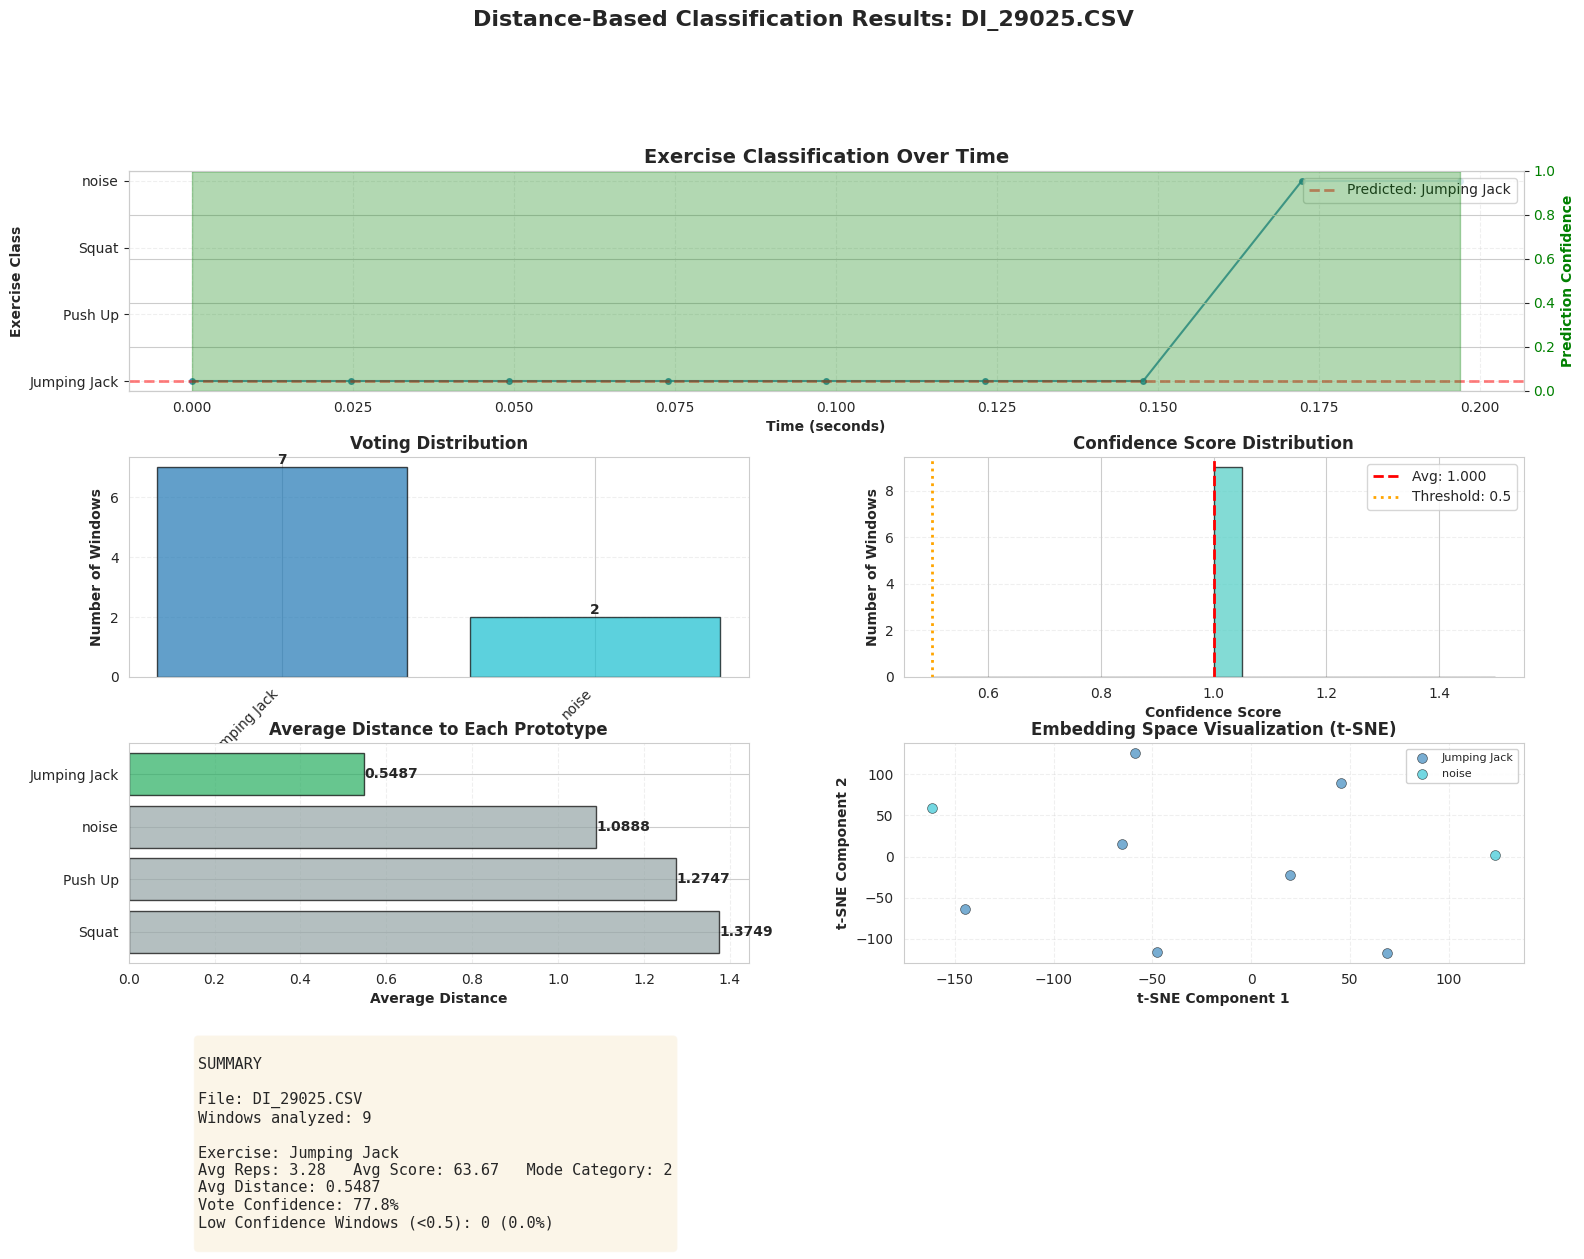

✅ Visualization complete. 9 windows plotted.


In [247]:
# =============================================================================
# STEP 8: VISUALIZE PREDICTIONS OVER TIME
# =============================================================================
print(f"\n📈 STEP 8: VISUALIZING PREDICTIONS OVER TIME")
print("="*80)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------
# 0️⃣ Verify data
# -----------------------------
if 'window_results' not in locals() or len(window_results) == 0:
    raise ValueError("No window-level prediction data found. Run classification first!")

# Extract arrays
window_predictions = np.array([w['pred_class'] for w in window_results])
window_confidences = np.array([w['confidence'] for w in window_results])
reps_array = np.array([w['repetition_count'] if w['repetition_count'] is not None else np.nan for w in window_results])
score_array = np.array([w['quality_score'] if w['quality_score'] is not None else np.nan for w in window_results])
category_array = np.array([w['quality_category'] if w['quality_category'] is not None else np.nan for w in window_results])
n_windows = len(window_predictions)

# Map class indices to names
if 'exercise_mapping' in globals():
    label_to_name = {idx: name for name, idx in exercise_mapping.items()}
else:
    unique_classes = np.unique(window_predictions)
    label_to_name = {idx: f'Class_{idx}' for idx in unique_classes}
class_names = [label_to_name[i] for i in sorted(label_to_name.keys())]

# Time axis
if 'STRIDE' in globals() and 'FS' in globals():
    window_times = np.arange(n_windows) * (STRIDE / FS)
    time_label = "Time (seconds)"
elif 'STRIDE' in globals() and 'SAMPLING_RATE' in globals():
    window_times = np.arange(n_windows) * (STRIDE / SAMPLING_RATE)
    time_label = "Time (seconds)"
elif 'WINDOW_SIZE' in globals() and 'SAMPLING_RATE' in globals():
    window_times = np.arange(n_windows) * (WINDOW_SIZE / SAMPLING_RATE)
    time_label = "Time (seconds)"
else:
    window_times = np.arange(n_windows)
    time_label = "Window Index"

# -----------------------------
# 1️⃣ Create figure
# -----------------------------
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.25)

# -----------------------------
# 2️⃣ Exercise Class Over Time
# -----------------------------
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(window_times, window_predictions, marker='o', markersize=4, linewidth=1.5, color='#2E86AB', alpha=0.8)
ax1.set_yticks(range(len(class_names)))
ax1.set_yticklabels(class_names)
ax1.set_ylabel("Exercise Class", fontweight='bold')
ax1.set_title("Exercise Classification Over Time", fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_xlabel(time_label, fontweight='bold')

# Highlight predicted exercise
if 'predicted_exercise_idx' in locals():
    ax1.axhline(y=predicted_exercise_idx, color='red', linestyle='--', linewidth=2,
                alpha=0.5, label=f'Predicted: {predicted_exercise_name}')
    ax1.legend(loc='upper right')

# Confidence overlay
if window_confidences is not None and len(window_confidences) == n_windows:
    ax1_twin = ax1.twinx()
    ax1_twin.fill_between(window_times, 0, window_confidences, alpha=0.3, color='green', label='Confidence')
    ax1_twin.plot(window_times, window_confidences, color='green', linewidth=1, alpha=0.7)
    ax1_twin.set_ylabel('Prediction Confidence', color='green', fontweight='bold')
    ax1_twin.set_ylim([0, 1])
    ax1_twin.tick_params(axis='y', labelcolor='green')

# -----------------------------
# 3️⃣ Voting Distribution
# -----------------------------
ax2 = fig.add_subplot(gs[1, 0])
unique_classes, counts = np.unique(window_predictions, return_counts=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))
bars = ax2.bar([label_to_name[int(c)] for c in unique_classes], counts,
               color=[colors[i] for i in range(len(unique_classes))], alpha=0.7, edgecolor='black')
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')
ax2.set_ylabel("Number of Windows", fontweight='bold')
ax2.set_title("Voting Distribution", fontsize=12, fontweight='bold')
ax2.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# -----------------------------
# 4️⃣ Confidence Distribution
# -----------------------------
ax3 = fig.add_subplot(gs[1, 1])
if window_confidences is not None:
    ax3.hist(window_confidences, bins=20, color='#4ECDC4', alpha=0.7, edgecolor='black')
    avg_conf = np.mean(window_confidences)
    ax3.axvline(x=avg_conf, color='red', linestyle='--', linewidth=2, label=f'Avg: {avg_conf:.3f}')
    ax3.axvline(x=0.5, color='orange', linestyle=':', linewidth=2, label='Threshold: 0.5')
    ax3.set_xlabel("Confidence Score", fontweight='bold')
    ax3.set_ylabel("Number of Windows", fontweight='bold')
    ax3.set_title("Confidence Score Distribution", fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, axis='y', linestyle='--', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'No confidence data', ha='center', va='center', transform=ax3.transAxes, fontsize=12)

# -----------------------------
# 5️⃣ Average Distance to Each Prototype
# -----------------------------
ax4 = fig.add_subplot(gs[2, 0])
if 'avg_distances_per_class' in locals():
    sorted_distances = sorted(avg_distances_per_class.items(), key=lambda x: x[1])
    classes_sorted = [label_to_name.get(idx, f'Class_{idx}') for idx, _ in sorted_distances]
    distances_sorted = [dist for _, dist in sorted_distances]
    colors_dist = ['#27AE60' if idx == predicted_exercise_idx else '#95A5A6' for idx, _ in sorted_distances]
    bars = ax4.barh(classes_sorted, distances_sorted, color=colors_dist, alpha=0.7, edgecolor='black')
    for i, (bar, dist) in enumerate(zip(bars, distances_sorted)):
        ax4.text(dist, bar.get_y() + bar.get_height()/2., f'{dist:.4f}', ha='left', va='center', fontweight='bold')
    ax4.set_xlabel("Average Distance", fontweight='bold')
    ax4.set_title("Average Distance to Each Prototype", fontsize=12, fontweight='bold')
    ax4.grid(True, axis='x', linestyle='--', alpha=0.3)
    ax4.invert_yaxis()
else:
    ax4.text(0.5, 0.5, 'No distance data', ha='center', va='center', transform=ax4.transAxes, fontsize=12)

# -----------------------------
# 6️⃣ Embedding Space (t-SNE/PCA)
# -----------------------------
ax5 = fig.add_subplot(gs[2, 1])
if 'val_emb' in locals():
    embeddings = val_emb
    preds_plot = window_predictions[:len(embeddings)]
    if embeddings.shape[1] > 2:
        from sklearn.manifold import TSNE
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1))
        embeddings_2d = tsne.fit_transform(embeddings)
        reduction_method = "t-SNE"
    else:
        embeddings_2d = embeddings
        reduction_method = "2D"

    unique_preds = np.unique(preds_plot)
    colors_map = plt.cm.tab10(np.linspace(0, 1, len(unique_preds)))
    for i, pred_class in enumerate(unique_preds):
        mask = preds_plot == pred_class
        ax5.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], c=[colors_map[i]], label=label_to_name.get(pred_class,f'Class_{pred_class}'), alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

    ax5.set_xlabel(f"{reduction_method} Component 1", fontweight='bold')
    ax5.set_ylabel(f"{reduction_method} Component 2", fontweight='bold')
    ax5.set_title(f"Embedding Space Visualization ({reduction_method})", fontsize=12, fontweight='bold')
    ax5.legend(loc='best', fontsize=8, framealpha=0.9)
    ax5.grid(True, linestyle='--', alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'No embedding data available', ha='center', va='center', transform=ax5.transAxes, fontsize=12)

# -----------------------------
# 7️⃣ Summary Text Box
# -----------------------------
ax6 = fig.add_subplot(gs[3, :])
ax6.axis('off')

summary_text = f"""
SUMMARY

File: {os.path.basename(FILE_PATH) if 'FILE_PATH' in globals() else 'Unknown'}
Windows analyzed: {n_windows}

Exercise: {predicted_exercise_name if 'predicted_exercise_name' in locals() else 'N/A'}
Avg Reps: {np.nanmean(reps_array):.2f}   Avg Score: {np.nanmean(score_array):.2f}   Mode Category: {Counter(category_array[~np.isnan(category_array)]).most_common(1)[0][0] if np.any(~np.isnan(category_array)) else 'N/A'}
Avg Distance: {min(avg_distances_per_class.values()):.4f}  
Vote Confidence: {confidence_pct:.1f}%  
Low Confidence Windows (<0.5): {np.sum(window_confidences<0.5) if window_confidences is not None else 0} ({np.sum(window_confidences<0.5)/n_windows*100 if window_confidences is not None else 0:.1f}%)
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=11, verticalalignment='top', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

fig.suptitle(f'Distance-Based Classification Results: {os.path.basename(FILE_PATH) if "FILE_PATH" in globals() else "Unknown"}', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()
print(f"✅ Visualization complete. {n_windows} windows plotted.")
